In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    auc
)
from scipy import stats
import warnings
import time
import requests

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam

print(f"TensorFlow version: {tf.__version__}")

warnings.filterwarnings("ignore")
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.dpi"] = 120

print("All libraries imported successfully")

TensorFlow version: 2.20.0
✓ All libraries imported successfully


In [ ]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# ============================================================================
# LOAD DATASET
# ============================================================================

LOAD_ORIGINAL = Fasle

print("=" * 80)
if LOAD_ORIGINAL:
    print("MODE: LOADING ORIGINAL DATA")
    print("=" * 80)

    # Load original UNSW-NB15
    print("\nLoading UNSW-NB15 dataset...")
    df_unsw = pd.read_csv('/content/drive/MyDrive/AI_IDS_project/UNSW_NB15_training-set.csv')
    print(f"Dataset loaded: {df_unsw.shape[0]:,} rows × {df_unsw.shape[1]} columns")

else:
    print("MODE: LOADING PRE-PROCESSED DATA (REPRODUCIBLE)")
    print("=" * 80)

    # Load pre-processed dataset with OSINT
    print("\nLoading pre-processed dataset with OSINT features...")

    try:
        df_unsw = pd.read_csv('/content/drive/MyDrive/AI_IDS_project/UNSW_NB15_with_OSINT.csv')
        print(f"✓ Dataset loaded: {df_unsw.shape[0]:,} rows × {df_unsw.shape[1]} columns")

        # Verify OSINT features
        osint_features = ['protocol_cve_score', 'service_epss_score', 'port_behavior_risk']
        print("\nOSINT features verified:")
        for feat in osint_features:
            if feat in df_unsw.columns:
                print(f"  ✓ {feat}")


    except FileNotFoundError:
        print("\n⚠️  Pre-processed file not found!")

MODE: LOADING ORIGINAL DATA

Loading UNSW-NB15 dataset...
✓ Dataset loaded: 82,332 rows × 45 columns

📝 You will need to run Cells 14-16 to generate OSINT features


In [ ]:
# Basic overview
print("Attack categories:")
print(df_unsw['attack_cat'].value_counts())

print("\nLabel distribution:")
print(df_unsw['label'].value_counts())

Attack categories:
attack_cat
Normal            37000
Generic           18871
Exploits          11132
Fuzzers            6062
DoS                4089
Reconnaissance     3496
Analysis            677
Backdoor            583
Shellcode           378
Worms                44
Name: count, dtype: int64

Label distribution:
label
1    45332
0    37000
Name: count, dtype: int64


DATA CLEANING

In [ ]:
print("=" * 80)
print("DATA CLEANING")
print("=" * 80)

# Data quality check
print(f"\nTotal rows:       {len(df_unsw):,}")
print(f"Total columns:    {len(df_unsw.columns)}")
print(f"Null values:      {df_unsw.isnull().sum().sum()}")
print(f"Duplicate rows:   {df_unsw.duplicated().sum()}")

missing_unsw = df_unsw.isnull().sum()
if missing_unsw.sum() == 0:
    print("No missing values detected")
else:
    print("\nColumns with missing values:")
    print(missing_unsw[missing_unsw > 0])

# Fill NaN in attack_cat
df_unsw['attack_cat'] = df_unsw['attack_cat'].fillna('Normal')

print(f"\nData cleaning complete. Final shape: {df_unsw.shape}")

DATA CLEANING

Total rows:       82,332
Total columns:    45
Null values:      0
Duplicate rows:   0
✓ No missing values detected

✓ Data cleaning complete. Final shape: (82332, 45)


EXPLORATORY DATA ANALYSIS

In [ ]:
print("\n" + "=" * 80)
print("EXPLORATORY DATA ANALYSIS")
print("=" * 80)

# Class Distribution
label_counts = df_unsw['label'].value_counts().sort_index()
attack_counts = df_unsw['attack_cat'].value_counts()

print("\nBinary classification:")
print(f"  Normal (0): {label_counts[0]:,} ({label_counts[0]/len(df_unsw)*100:.2f}%)")
print(f"  Attack (1): {label_counts[1]:,} ({label_counts[1]/len(df_unsw)*100:.2f}%)")

print("\nAttack categories:")
for cat, count in attack_counts.items():
    pct = count / len(df_unsw) * 100
    print(f"  {cat:15s}: {count:6,} ({pct:5.2f}%)")


EXPLORATORY DATA ANALYSIS

Binary classification:
  Normal (0): 37,000 (44.94%)
  Attack (1): 45,332 (55.06%)

Attack categories:
  Normal         : 37,000 (44.94%)
  Generic        : 18,871 (22.92%)
  Exploits       : 11,132 (13.52%)
  Fuzzers        :  6,062 ( 7.36%)
  DoS            :  4,089 ( 4.97%)
  Reconnaissance :  3,496 ( 4.25%)
  Analysis       :    677 ( 0.82%)
  Backdoor       :    583 ( 0.71%)
  Shellcode      :    378 ( 0.46%)
  Worms          :     44 ( 0.05%)


EDA: Visualize Class Distribution

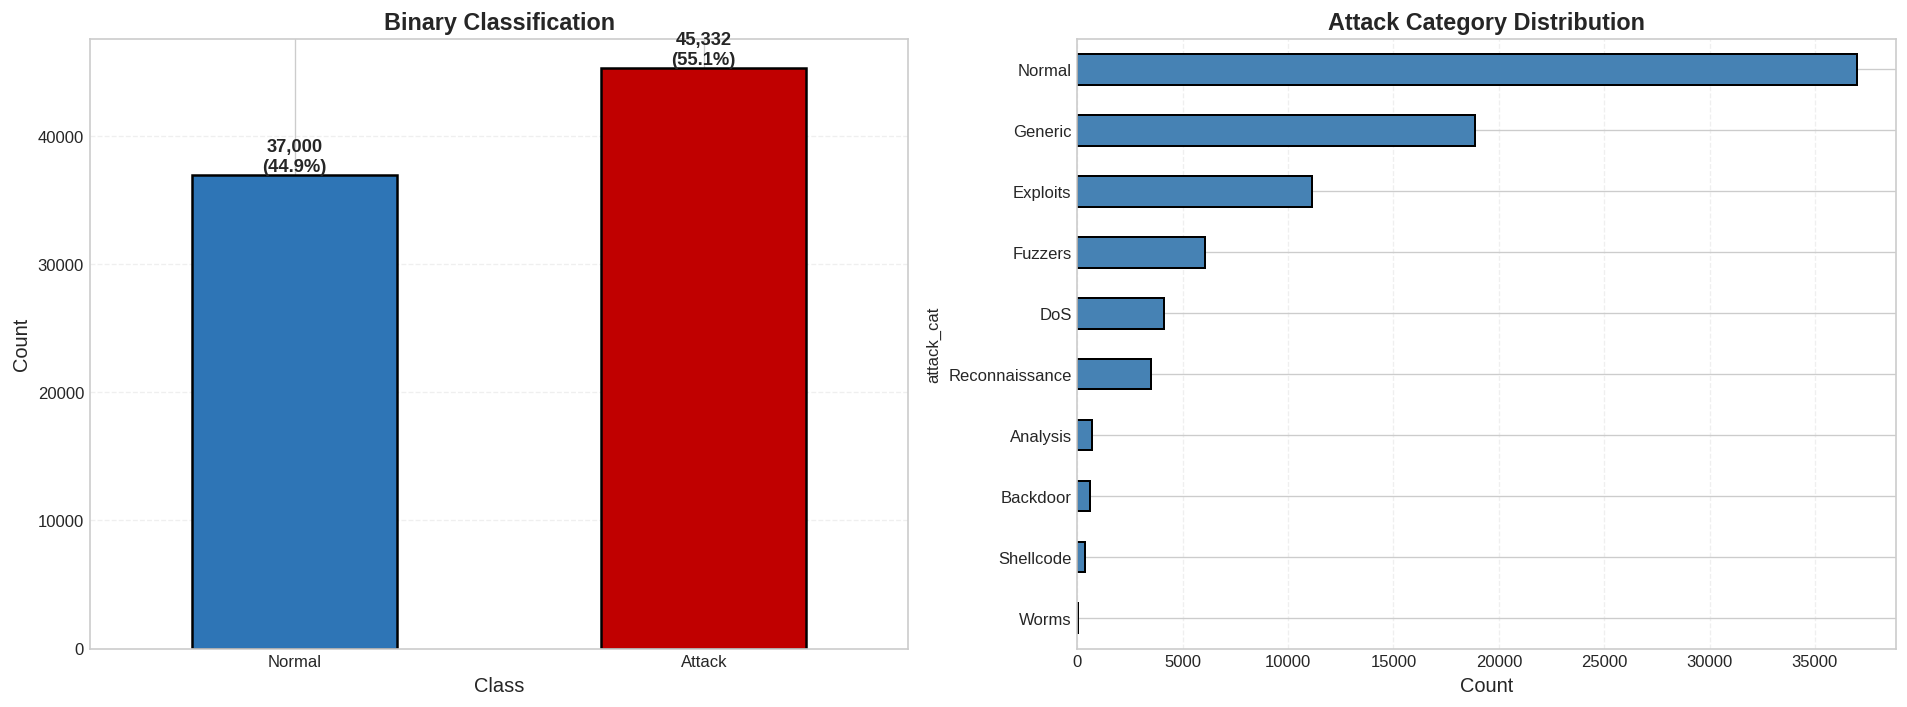

✓ Saved: eda_01_class_distribution.png


In [ ]:
# Visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Binary classification
label_counts.plot(
    kind='bar',
    ax=axes[0],
    color=['#2E75B6', '#C00000'],
    edgecolor='black',
    linewidth=1.5
)
axes[0].set_title('Binary Classification', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Class', fontsize=12)
axes[0].set_ylabel('Count', fontsize=12)
axes[0].set_xticklabels(['Normal', 'Attack'], rotation=0)
axes[0].grid(axis='y', alpha=0.3, linestyle='--')

for i, (idx, val) in enumerate(label_counts.items()):
    pct = val / len(df_unsw) * 100
    axes[0].text(i, val, f'{val:,}\n({pct:.1f}%)',
                ha='center', va='bottom', fontsize=11, fontweight='bold')

# Attack categories
attack_counts.sort_values(ascending=True).plot(
    kind='barh',
    ax=axes[1],
    color='steelblue',
    edgecolor='black',
    linewidth=1.2
)
axes[1].set_title('Attack Category Distribution', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Count', fontsize=12)
axes[1].grid(axis='x', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.savefig('eda_01_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print("Saved: eda_01_class_distribution.png")

 Statistical Summary

In [ ]:
# Statistical Summary
print("\nDescriptive statistics:")
display(df_unsw.describe())


Descriptive statistics:


,id,dur,spkts,dpkts,sbytes,dbytes,rate,sttl,dttl,sload,...,ct_src_dport_ltm,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,label
count,82332.000000,82332.000000,82332.000000,82332.000000,8.233200e+04,8.233200e+04,8.233200e+04,82332.000000,82332.000000,8.233200e+04,...,82332.000000,82332.000000,82332.000000,82332.000000,82332.000000,82332.000000,82332.000000,82332.000000,82332.000000,82332.000000
mean,41166.500000,1.006756,18.666472,17.545936,7.993908e+03,1.323379e+04,8.241089e+04,180.967667,95.713003,6.454902e+07,...,4.928898,3.663011,7.456360,0.008284,0.008381,0.129743,6.468360,9.164262,0.011126,0.550600
std,23767.345519,4.710444,133.916353,115.574086,1.716423e+05,1.514715e+05,1.486204e+05,101.513358,116.667722,1.798618e+08,...,8.389545,5.915386,11.415191,0.091171,0.092485,0.638683,8.543927,11.121413,0.104891,0.497436
min,1.000000,0.000000,1.000000,0.000000,2.400000e+01,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000e+00,...,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000
25%,20583.750000,0.000008,2.000000,0.000000,1.140000e+02,0.000000e+00,2.860611e+01,62.000000,0.000000,1.120247e+04,...,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000,2.000000,0.000000,0.000000
50%,41166.500000,0.014138,6.000000,2.000000,5.340000e+02,1.780000e+02,2.650177e+03,254.000000,29.000000,5.770032e+05,...,1.000000,1.000000,3.000000,0.000000,0.000000,0.000000,3.000000,5.000000,0.000000,1.000000
75%,61749.250000,0.719360,12.000000,10.000000,1.280000e+03,9.560000e+02,1.111111e+05,254.000000,252.000000,6.514286e+07,...,4.000000,3.000000,6.000000,0.000000,0.000000,0.000000,7.000000,11.000000,0.000000,1.000000
max,82332.000000,59.999989,10646.000000,11018.000000,1.435577e+07,1.465753e+07,1.000000e+06,255.000000,253.000000,5.268000e+09,...,59.000000,38.000000,63.000000,2.000000,2.000000,16.000000,60.000000,62.000000,1.000000,1.000000


EDA: Feature Distributions

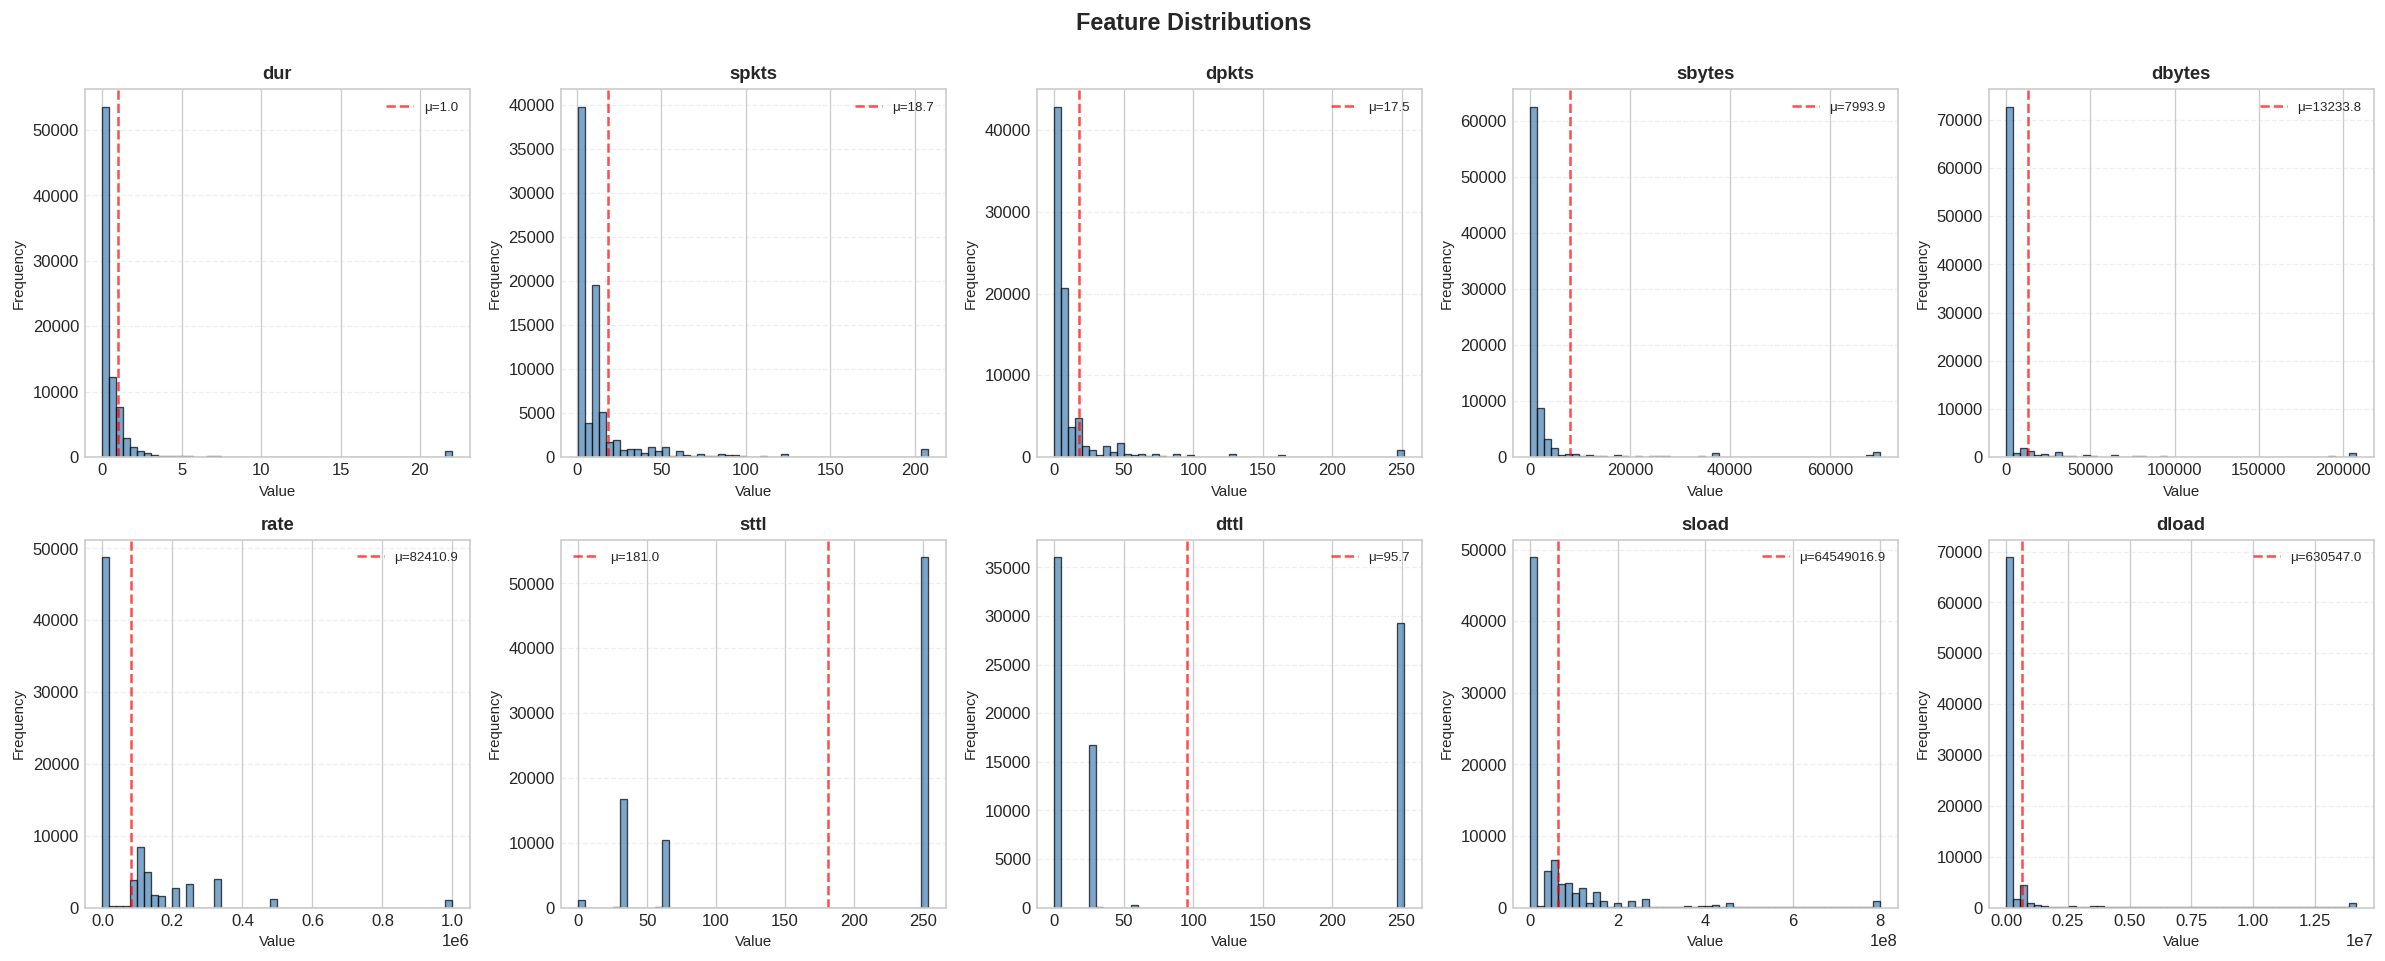

✓ Saved: eda_02_feature_distributions.png


In [ ]:
# Feature Distributions
key_features = ['dur', 'spkts', 'dpkts', 'sbytes', 'dbytes',
                'rate', 'sttl', 'dttl', 'sload', 'dload']

fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.ravel()

for i, feat in enumerate(key_features):
    data = df_unsw[feat].dropna()
    q01, q99 = data.quantile([0.01, 0.99])
    data_clipped = data.clip(q01, q99)

    axes[i].hist(data_clipped, bins=50, color='steelblue',
                edgecolor='black', alpha=0.7, linewidth=0.8)
    axes[i].set_title(f'{feat}', fontsize=11, fontweight='bold')
    axes[i].set_xlabel('Value', fontsize=9)
    axes[i].set_ylabel('Frequency', fontsize=9)
    axes[i].grid(axis='y', alpha=0.3, linestyle='--')

    mean_val = data.mean()
    axes[i].axvline(mean_val, color='red', linestyle='--',
                   linewidth=1.5, alpha=0.7, label=f'μ={mean_val:.1f}')
    axes[i].legend(fontsize=8)

plt.suptitle('Feature Distributions', fontsize=14, fontweight='bold', y=0.995)
plt.tight_layout()
plt.savefig('eda_02_feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

print("Saved: eda_02_feature_distributions.png")

Correlation Analysis


Top 15 features correlated with label:
   1. sttl                : 0.5042
   2. swin                : 0.4145
   3. ct_dst_sport_ltm    : 0.3937
   4. dwin                : 0.3693
   5. ct_src_dport_ltm    : 0.3415
   6. rate                : 0.3286
   7. ct_state_ttl        : 0.3185
   8. ct_srv_dst          : 0.2929
   9. ct_srv_src          : 0.2902
  10. dtcpb               : 0.2829
  11. stcpb               : 0.2814
  12. dload               : 0.2805
  13. ct_dst_src_ltm      : 0.2800
  14. ct_src_ltm          : 0.2765
  15. ct_dst_ltm          : 0.2580


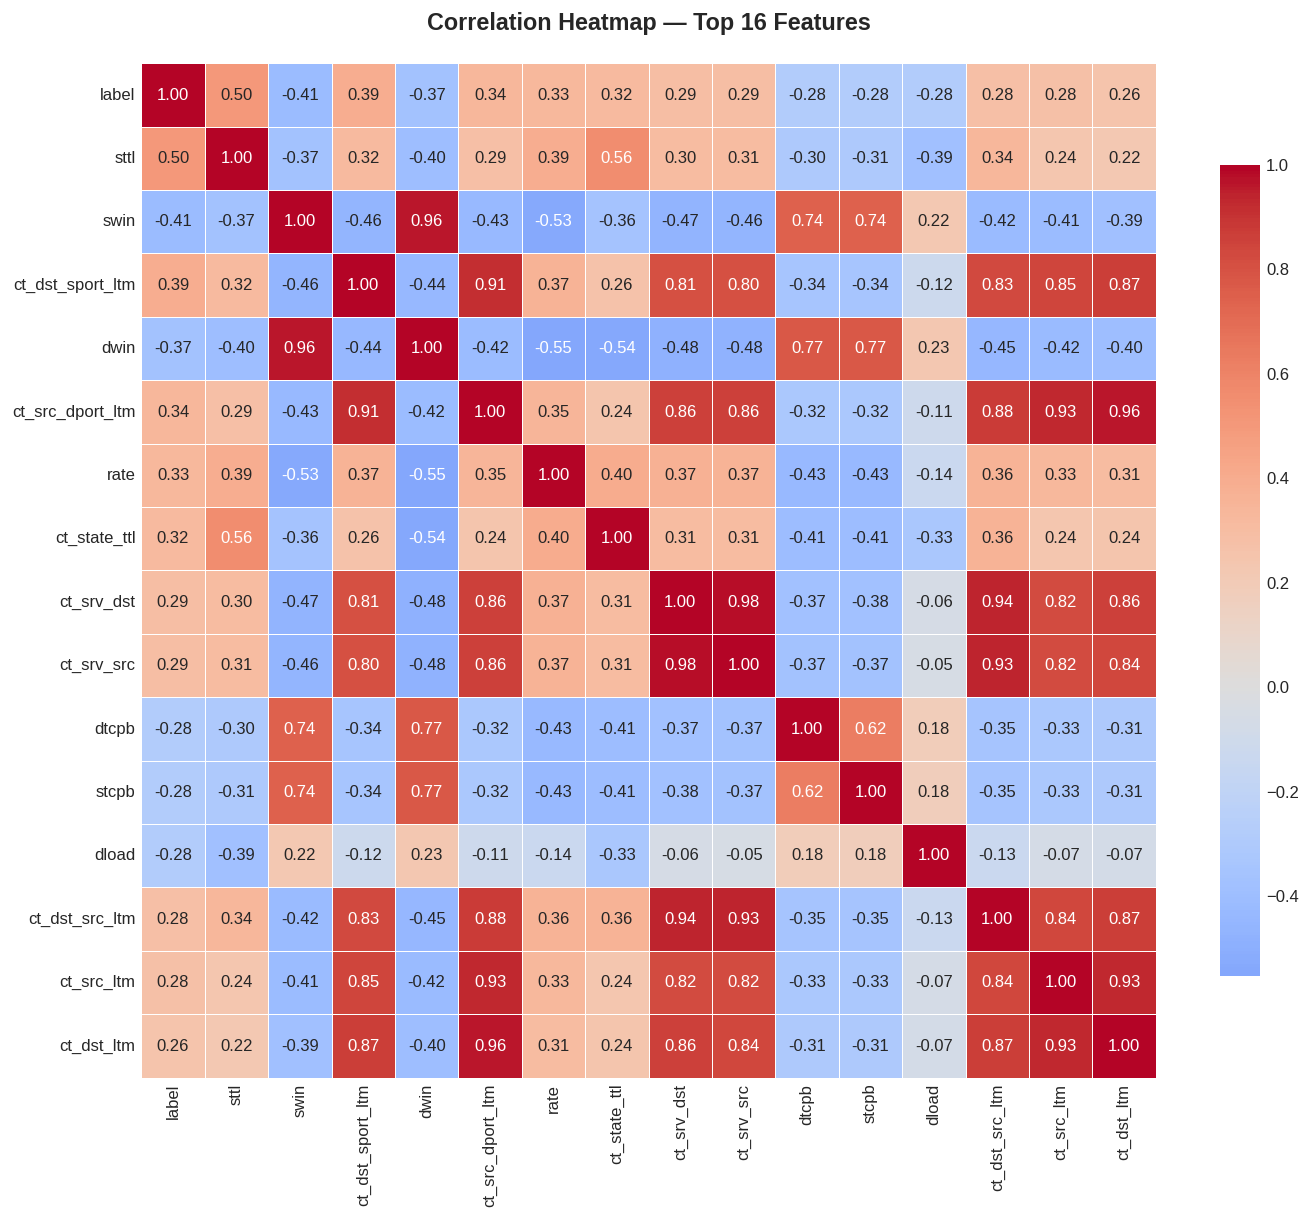

✓ Saved: eda_03_correlation_heatmap.png


In [ ]:
# Correlation Analysis
numeric_cols = df_unsw.select_dtypes(include=[np.number]).columns.tolist()
if 'id' in numeric_cols:
    numeric_cols.remove('id')

numeric_features = df_unsw[numeric_cols]
corr_with_label = numeric_features.corr()['label'].abs().sort_values(ascending=False)

print("\nTop 15 features correlated with label:")
for i, (feat, corr) in enumerate(corr_with_label[1:16].items(), 1):
    print(f"  {i:2d}. {feat:20s}: {corr:.4f}")

# Heatmap
top_corr_features = corr_with_label.head(16).index.tolist()

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(
    numeric_features[top_corr_features].corr(),
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8},
    ax=ax
)
ax.set_title('Correlation Heatmap — Top 16 Features',
             fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('eda_03_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print("Saved: eda_03_correlation_heatmap.png")

Protocol Distribution


Unique protocols: 131

Top 10 protocols:
  tcp     :  43,095 (52.34%)
  udp     :  29,418 (35.73%)
  unas    :   3,515 ( 4.27%)
  arp     :     987 ( 1.20%)
  ospf    :     676 ( 0.82%)
  sctp    :     324 ( 0.39%)
  any     :      96 ( 0.12%)
  gre     :      88 ( 0.11%)
  rsvp    :      64 ( 0.08%)
  ipv6    :      61 ( 0.07%)


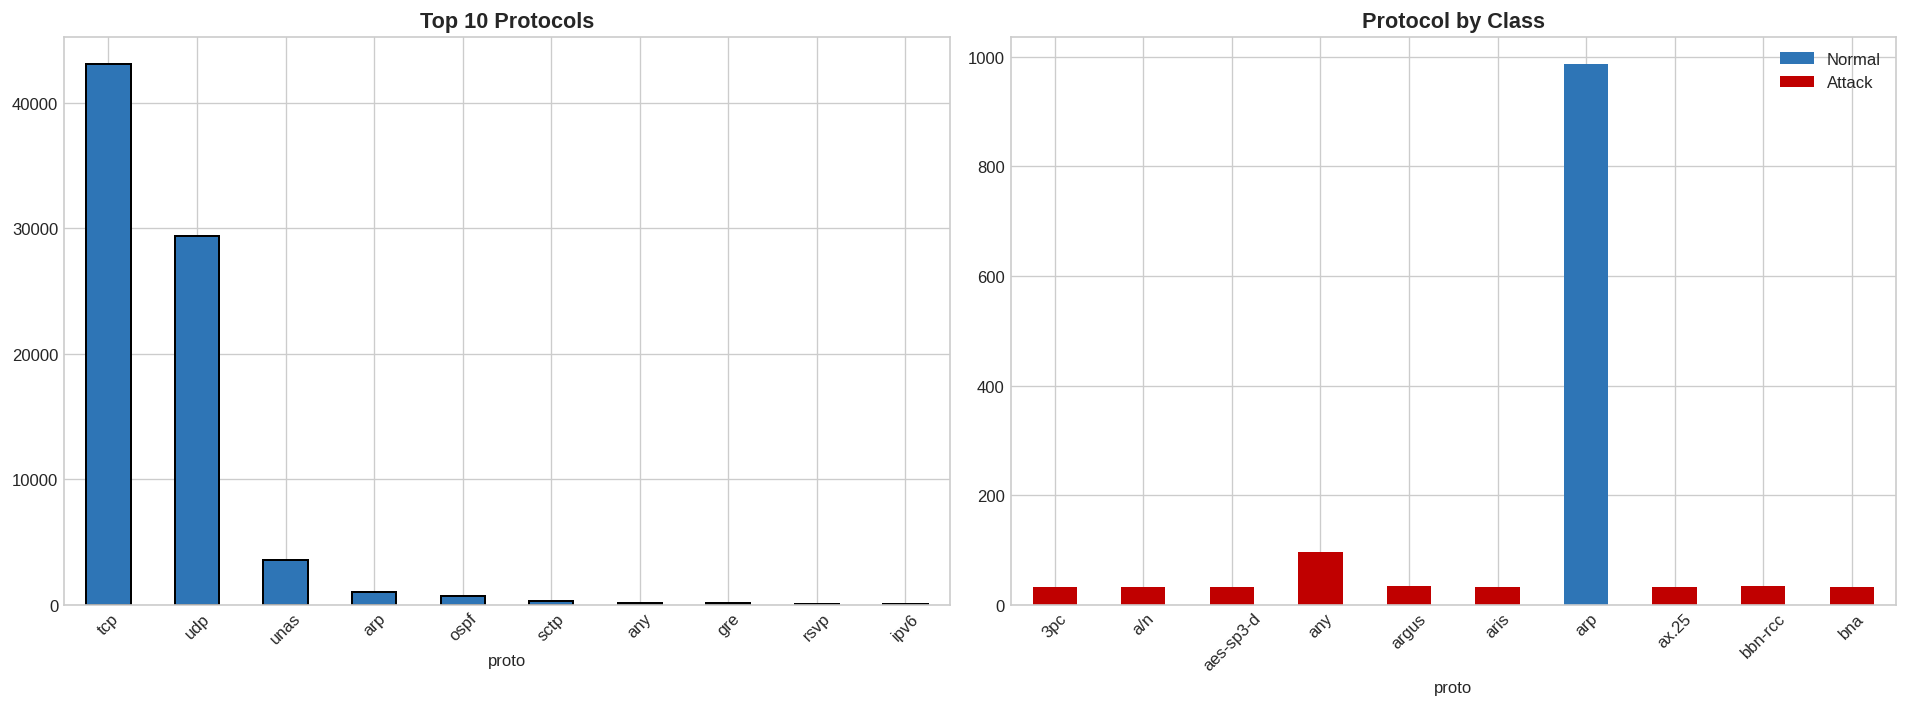

✓ Saved: eda_04_protocol_distribution.png


In [ ]:
# Protocol Distribution
proto_counts = df_unsw['proto'].value_counts()
proto_by_class = df_unsw.groupby(['proto', 'label']).size().unstack(fill_value=0)

print(f"\nUnique protocols: {df_unsw['proto'].nunique()}")
print("\nTop 10 protocols:")
for proto, count in proto_counts.head(10).items():
    pct = count / len(df_unsw) * 100
    print(f"  {proto:8s}: {count:7,} ({pct:5.2f}%)")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

proto_counts.head(10).plot(kind='bar', ax=axes[0], color='#2E75B6',
                            edgecolor='black', linewidth=1.2)
axes[0].set_title('Top 10 Protocols', fontsize=13, fontweight='bold')
axes[0].tick_params(axis='x', rotation=45)

proto_by_class.head(10).plot(kind='bar', stacked=True, ax=axes[1],
                              color=['#2E75B6', '#C00000'])
axes[1].set_title('Protocol by Class', fontsize=13, fontweight='bold')
axes[1].legend(['Normal', 'Attack'])
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('eda_04_protocol_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print("Saved: eda_04_protocol_distribution.png")

Service Distribution


Unique services: 13


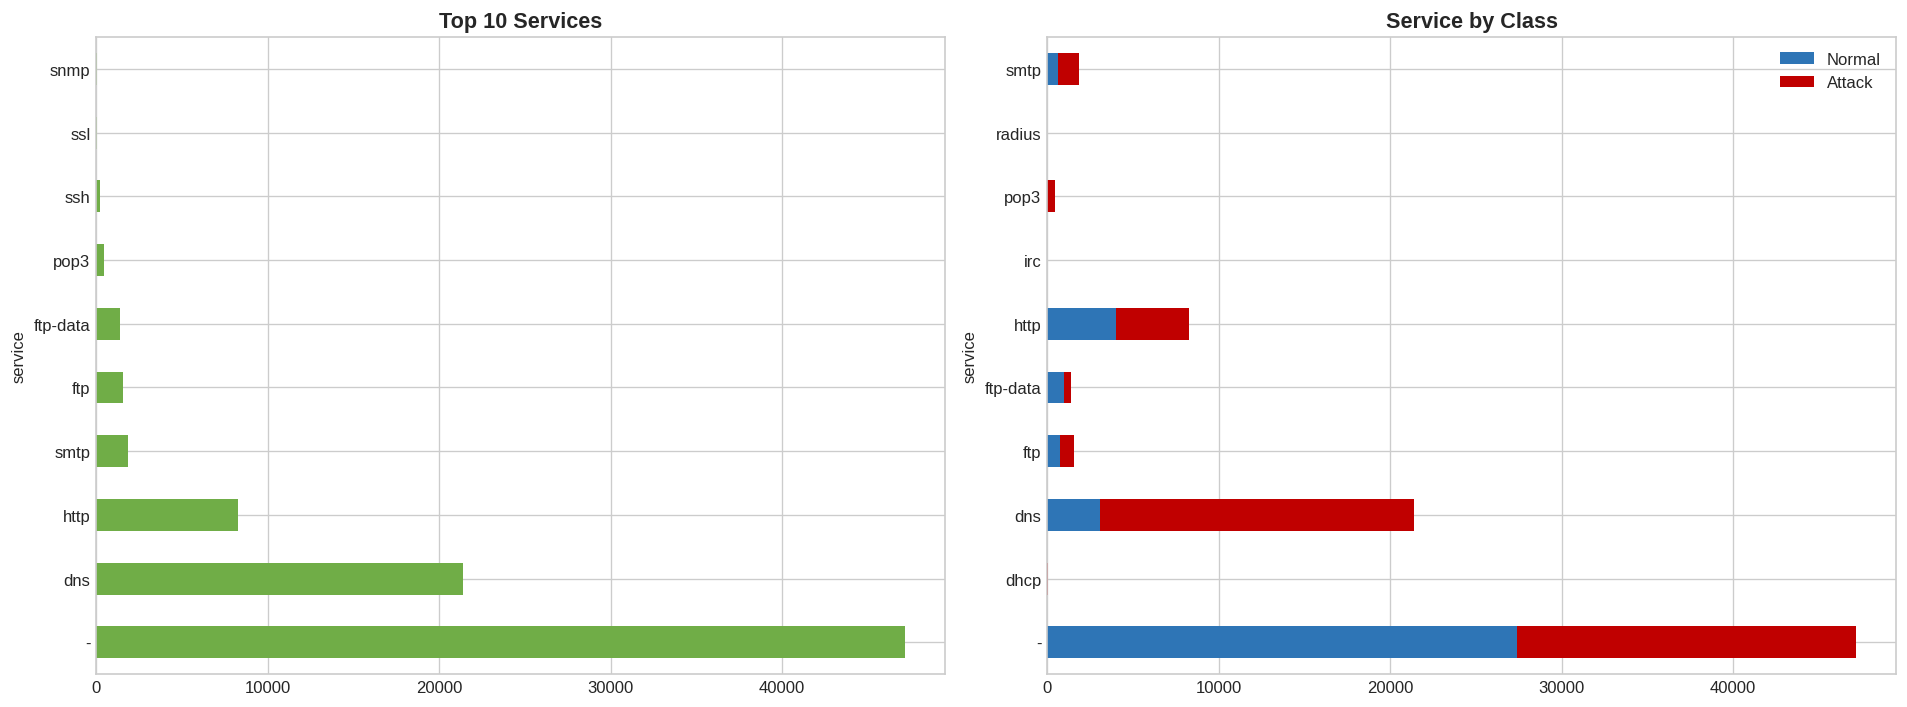

✓ Saved: eda_05_service_distribution.png


In [ ]:
# Service Distribution
service_counts = df_unsw['service'].value_counts()
service_by_class = df_unsw.groupby(['service', 'label']).size().unstack(fill_value=0)

print(f"\nUnique services: {df_unsw['service'].nunique()}")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

service_counts.head(10).plot(kind='barh', ax=axes[0], color='#70AD47')
axes[0].set_title('Top 10 Services', fontsize=13, fontweight='bold')

service_by_class.head(10).plot(kind='barh', stacked=True, ax=axes[1],
                                color=['#2E75B6', '#C00000'])
axes[1].set_title('Service by Class', fontsize=13, fontweight='bold')
axes[1].legend(['Normal', 'Attack'])

plt.tight_layout()
plt.savefig('eda_05_service_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print("Saved: eda_05_service_distribution.png")

Normal vs Attack Comparison

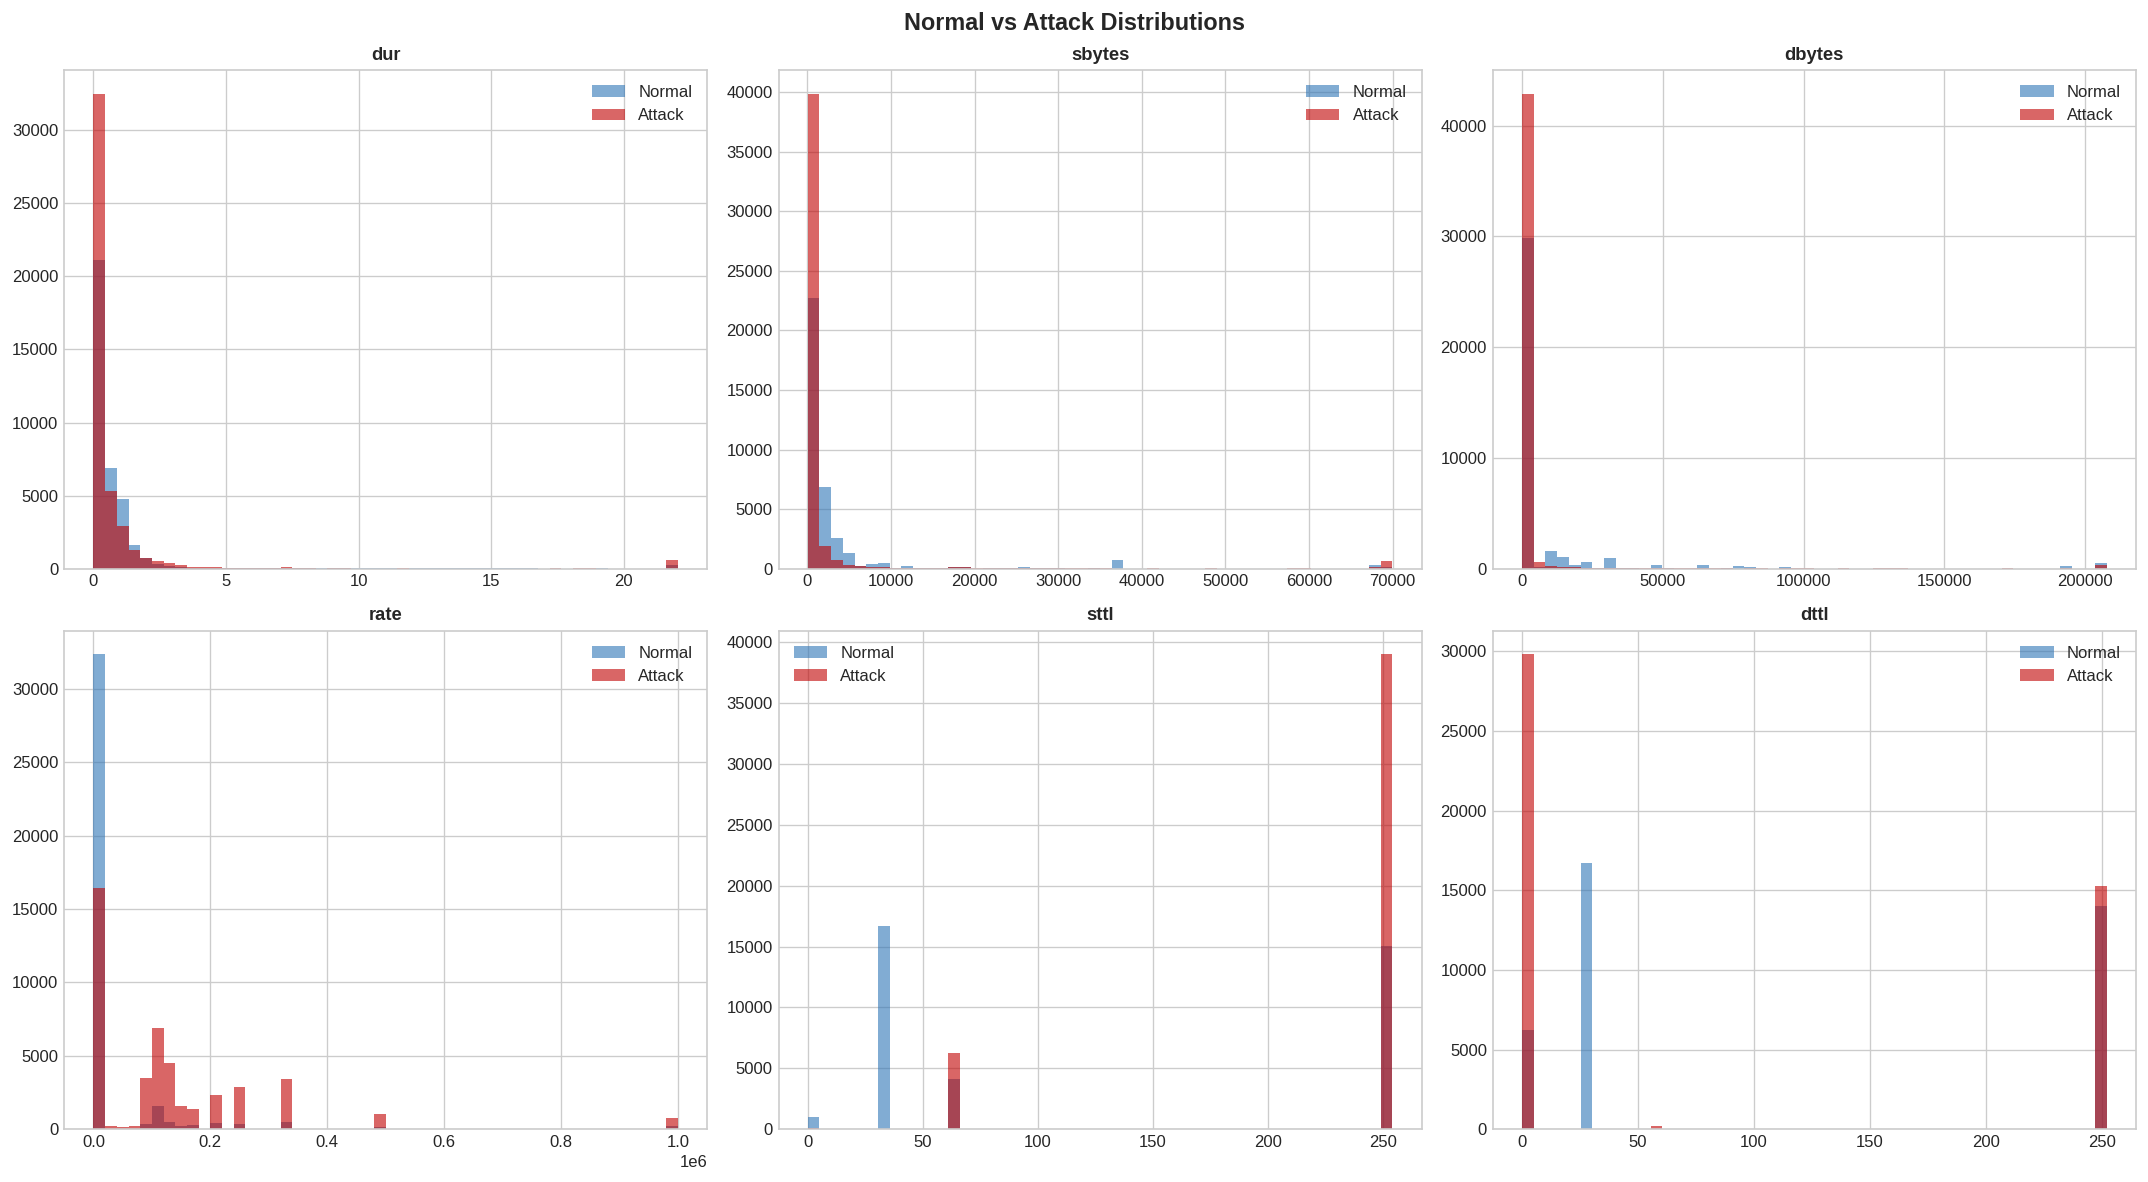

✓ EDA Complete — 7 visualizations generated


In [ ]:
# Normal vs Attack Feature Comparison
compare_features = ['dur', 'sbytes', 'dbytes', 'rate', 'sttl', 'dttl']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.ravel()

for i, feat in enumerate(compare_features):
    normal_data = df_unsw[df_unsw['label'] == 0][feat].dropna()
    attack_data = df_unsw[df_unsw['label'] == 1][feat].dropna()

    combined = pd.concat([normal_data, attack_data])
    q01, q99 = combined.quantile([0.01, 0.99])

    axes[i].hist(normal_data.clip(q01, q99), bins=50, alpha=0.6,
                label='Normal', color='#2E75B6')
    axes[i].hist(attack_data.clip(q01, q99), bins=50, alpha=0.6,
                label='Attack', color='#C00000')
    axes[i].set_title(f'{feat}', fontsize=11, fontweight='bold')
    axes[i].legend()

plt.suptitle('Normal vs Attack Distributions', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_07_normal_vs_attack.png', dpi=150, bbox_inches='tight')
plt.show()

print("EDA Complete — 7 visualizations generated")

OSINT FEATURE ENGINEERING

In [ ]:
print("\n" + "=" * 80)
print("OSINT FEATURE ENGINEERING")
print("=" * 80)
print("Creating 3 OSINT features from external threat intelligence...")

# ─────────────────────────────────────────────────────────────────────────────
# Protocol CVE Score from NVD API
# ─────────────────────────────────────────────────────────────────────────────

print("\n1. PROTOCOL CVE SCORE (NIST NVD API)")
print("-" * 80)

def get_nvd_score(keyword):
    """Fetch average CVSS score from NVD API for a protocol"""
    url = "https://services.nvd.nist.gov/rest/json/cves/2.0"
    headers = {
        "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36",
        "Accept": "application/json"
    }
    params = {'keywordSearch': keyword, 'resultsPerPage': 100}

    try:
        time.sleep(6.0)
        response = requests.get(url, params=params, headers=headers, timeout=15)

        if response.status_code != 200:
            return 0.20  # Default if API fails

        data = response.json()
        scores = []

        # Extract CVSS scores from CVEs
        for item in data.get('vulnerabilities', []):
            metrics = item.get('cve', {}).get('metrics', {})
            for version in ['cvssMetricV31', 'cvssMetricV30', 'cvssMetricV2']:
                if version in metrics:
                    scores.append(metrics[version][0]['cvssData']['baseScore'])
                    break

        if scores:
            # Normalize
            return round((sum(scores) / len(scores)) / 10, 4)

        return 0.15  # Default if no CVEs found

    except Exception as e:
        print(f"  Error fetching {keyword}: {e}")
        return 0.20

# Fetch scores for top protocols
top_protos = df_unsw['proto'].value_counts().index[:15].tolist()

print(f"Fetching CVE scores for {len(top_protos)} protocols...")
proto_cve_map = {}
for p in top_protos:
    score = get_nvd_score(p)
    proto_cve_map[p] = score
    print(f"  {p:8s}: {score:.4f}")

# Map to dataset
df_unsw['protocol_cve_score'] = df_unsw['proto'].map(proto_cve_map).fillna(0.10)

print(f"\nprotocol_cve_score created")
print(f"  Range: {df_unsw['protocol_cve_score'].min():.4f} - {df_unsw['protocol_cve_score'].max():.4f}")
print(f"  Mean:  {df_unsw['protocol_cve_score'].mean():.4f}")


OSINT FEATURE ENGINEERING
Creating 3 OSINT features from external threat intelligence...

1. PROTOCOL CVE SCORE (NIST NVD API)
--------------------------------------------------------------------------------
Fetching CVE scores for 15 protocols...
⏱ This will take ~90 seconds (6-second delay per request)

  Error fetching tcp: HTTPSConnectionPool(host='services.nvd.nist.gov', port=443): Read timed out. (read timeout=15)
  tcp     : 0.2000
  Error fetching udp: HTTPSConnectionPool(host='services.nvd.nist.gov', port=443): Read timed out. (read timeout=15)
  udp     : 0.2000
  unas    : 0.6833
  arp     : 0.6494
  ospf    : 0.6567
  sctp    : 0.6558
  any     : 0.6328
  gre     : 0.6629
  Error fetching rsvp: HTTPSConnectionPool(host='services.nvd.nist.gov', port=443): Read timed out. (read timeout=15)
  rsvp    : 0.2000
  ipv6    : 0.6420
  sep     : 0.6105
  sun-nd  : 0.1500
  swipe   : 0.5875
  mobile  : 0.6328
  pim     : 0.6693

✓ protocol_cve_score created
  Range: 0.1000 - 0.6833


OSINT Feature 2: Service EPSS Score (FIRST.org API)

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# Service EPSS Score from FIRST.org API
# ─────────────────────────────────────────────────────────────────────────────

print("\n2. SERVICE EPSS SCORE (FIRST.org API)")
print("-" * 80)

def get_epss_for_service(service_name):
    """Fetch EPSS (exploitation probability) score for a service"""
    try:
        # Step 1: Get CVE IDs from NVD
        nvd_url = "https://services.nvd.nist.gov/rest/json/cves/2.0"
        params = {'keywordSearch': service_name, 'resultsPerPage': 50}
        headers = {
            "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36",
            "Accept": "application/json"
        }

        time.sleep(6.0)
        nvd_response = requests.get(nvd_url, params=params, headers=headers, timeout=15)

        if nvd_response.status_code != 200:
            return 0.0

        nvd_data = nvd_response.json()
        cve_ids = []

        for item in nvd_data.get('vulnerabilities', []):
            cve_id = item.get('cve', {}).get('id')
            if cve_id:
                cve_ids.append(cve_id)

        if not cve_ids:
            return 0.0

        # Step 2: Query EPSS API with CVE IDs
        epss_url = "https://api.first.org/data/v1/epss"
        time.sleep(2.0)
        epss_params = {'cve': ','.join(cve_ids[:10])}  # Limit to 10 CVEs
        epss_response = requests.get(epss_url, params=epss_params, timeout=15)

        if epss_response.status_code != 200:
            return 0.0

        epss_data = epss_response.json()
        scores = []

        for entry in epss_data.get('data', []):
            epss = entry.get('epss')
            if epss:
                scores.append(float(epss))

        if scores:
            return round(sum(scores) / len(scores), 4)

        return 0.0

    except Exception as e:
        print(f"  Error fetching {service_name}: {e}")
        return 0.0

# Fetch EPSS scores for common services
top_services = ['http', 'ftp', 'ftp-data', 'smtp', 'pop3', 'dns',
                'snmp', 'ssl', 'dhcp', 'irc', 'radius', 'ssh']

print(f"Fetching EPSS scores for {len(top_services)} services...")
print("⏱ This will take ~2 minutes\n")

service_epss_map = {}
for svc in top_services:
    score = get_epss_for_service(svc)
    service_epss_map[svc] = score
    print(f"  {svc:12s}: {score:.4f}")

# Map to dataset
df_unsw['service_epss_score'] = df_unsw['service'].map(service_epss_map).fillna(0.0)

print(f"\nservice_epss_score created")
print(f"  Range: {df_unsw['service_epss_score'].min():.4f} - {df_unsw['service_epss_score'].max():.4f}")
print(f"  Mean:  {df_unsw['service_epss_score'].mean():.4f}")


2. SERVICE EPSS SCORE (FIRST.org API)
--------------------------------------------------------------------------------
Fetching EPSS scores for 12 services...
⏱ This will take ~2 minutes

  http        : 0.0324
  ftp         : 0.0184
  ftp-data    : 0.0000
  smtp        : 0.0162
  pop3        : 0.0226
  dns         : 0.0948
  Error fetching snmp: HTTPSConnectionPool(host='services.nvd.nist.gov', port=443): Read timed out. (read timeout=15)
  snmp        : 0.0000
  ssl         : 0.0291
  dhcp        : 0.0909
  irc         : 0.0364
  radius      : 0.0528
  Error fetching ssh: HTTPSConnectionPool(host='services.nvd.nist.gov', port=443): Read timed out. (read timeout=15)
  ssh         : 0.0000

✓ service_epss_score created
  Range: 0.0000 - 0.0948
  Mean:  0.0287


OSINT Feature 3: Port Behavior Risk

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# Port Behavior Risk (SANS ISC Logic)
# ─────────────────────────────────────────────────────────────────────────────

print("\n3. PORT BEHAVIOR RISK (SANS ISC Logic)")
print("-" * 80)

port_features = df_unsw[[
    'ct_src_dport_ltm',    # Source to destination port connection count
    'ct_dst_sport_ltm',    # Destination to source port connection count
    'ct_state_ttl'         # Connection state TTL
]].copy()

# Normalize each component
scaler_port = MinMaxScaler()
port_scaled = scaler_port.fit_transform(port_features)

# Weighted combination based on SANS ISC threat patterns
# 0.4 weight for each direction of port connections
# 0.2 weight for state TTL (supplementary signal)
df_unsw['port_behavior_risk'] = (
    0.4 * port_scaled[:, 0] +   # ct_src_dport_ltm
    0.4 * port_scaled[:, 1] +   # ct_dst_sport_ltm
    0.2 * port_scaled[:, 2]     # ct_state_ttl
)

print(f"port_behavior_risk created")
print(f"  Formula: 0.4×ct_src_dport_ltm + 0.4×ct_dst_sport_ltm + 0.2×ct_state_ttl")
print(f"  Range: {df_unsw['port_behavior_risk'].min():.4f} - {df_unsw['port_behavior_risk'].max():.4f}")
print(f"  Mean:  {df_unsw['port_behavior_risk'].mean():.4f}")

print("\n" + "=" * 80)
print("OSINT FEATURE ENGINEERING COMPLETE")
print("=" * 80)
print("\nCreated 3 OSINT features:")
print("  1. protocol_cve_score  (NVD API)")
print("  2. service_epss_score  (FIRST.org API)")
print("  3. port_behavior_risk  (SANS ISC logic)")


3. PORT BEHAVIOR RISK (SANS ISC Logic)
--------------------------------------------------------------------------------
✓ port_behavior_risk created
  Formula: 0.4×ct_src_dport_ltm + 0.4×ct_dst_sport_ltm + 0.2×ct_state_ttl
  Range: 0.0000 - 0.8046
  Mean:  0.1015

✓ OSINT FEATURE ENGINEERING COMPLETE

Created 3 OSINT features:
  1. protocol_cve_score  (NVD API)
  2. service_epss_score  (FIRST.org API)
  3. port_behavior_risk  (SANS ISC logic)


In [ ]:
# ============================================================================
# SAVE PROCESSED DATASET
# ============================================================================

print("\n" + "=" * 80)
print("SAVING PROCESSED DATASET WITH OSINT FEATURES")
print("=" * 80)

save_path = '/content/drive/MyDrive/AI_IDS_project/UNSW_NB15_with_OSINT7.csv'
df_unsw.to_csv(save_path, index=False)

print(f"\n Saved to: {save_path}")
print(f"  Dataset shape: {df_unsw.shape}")

print("\n" + "=" * 80)
print("FOR REPRODUCIBILITY:")
print("=" * 80)
print("From now on, go to Cell 4 and change:")
print(" LOAD_ORIGINAL = False")
print("\nThis will load the saved file instead of regenerating OSINT")
print("=" * 80)

# Verify OSINT features
print("\nOSINT features saved:")
for feat in ['protocol_cve_score', 'service_epss_score', 'port_behavior_risk']:
    print(f"  {feat}: mean={df_unsw[feat].mean():.4f}")


SAVING PROCESSED DATASET WITH OSINT FEATURES

✓ Saved to: /content/drive/MyDrive/AI_IDS_project/UNSW_NB15_with_OSINT7.csv
  Dataset shape: (82332, 48)

⚠️  FOR REPRODUCIBILITY:
From now on, go to Cell 4 and change:
  LOAD_ORIGINAL = False

This will load the saved file instead of regenerating OSINT

OSINT features saved:
  ✓ protocol_cve_score: mean=0.5551
  ✓ service_epss_score: mean=0.0287
  ✓ port_behavior_risk: mean=0.1015


Feature Selection and Train/Test Split

In [ ]:
print("\n" + "=" * 80)
print("DATA PREPROCESSING")
print("=" * 80)

# ─────────────────────────────────────────────────────────────────────────────
# Feature Selection
# ─────────────────────────────────────────────────────────────────────────────

print("\nFeature Selection:")

# Experiment A: WITHOUT OSINT (baseline)
drop_cols_A = ['label', 'attack_cat', 'id',
               'protocol_cve_score', 'service_epss_score', 'port_behavior_risk']
X_A = df_unsw.drop(columns=drop_cols_A, errors='ignore')
X_A = X_A.select_dtypes(include=[np.number])
y = df_unsw['label']

print(f"  Experiment A (Baseline): {X_A.shape[1]} features")

# Experiment B: WITH OSINT (hybrid)
drop_cols_B = ['label', 'attack_cat', 'id']
X_B = df_unsw.drop(columns=drop_cols_B, errors='ignore')
X_B = X_B.select_dtypes(include=[np.number])

print(f"  Experiment B (Hybrid):   {X_B.shape[1]} features (+3 OSINT)")

# ─────────────────────────────────────────────────────────────────────────────
# Train/Test Split (same random_state for fair comparison)
# ─────────────────────────────────────────────────────────────────────────────

print("\nTrain/Test Split (80/20, stratified):")

# Experiment A
X_A_train, X_A_test, y_A_train, y_A_test = train_test_split(
    X_A, y, test_size=0.2, random_state=42, stratify=y
)
print(f"  Experiment A - Train: {X_A_train.shape}, Test: {X_A_test.shape}")

# Experiment B
X_B_train, X_B_test, y_B_train, y_B_test = train_test_split(
    X_B, y, test_size=0.2, random_state=42, stratify=y
)
print(f"  Experiment B - Train: {X_B_train.shape}, Test: {X_B_test.shape}")

# ─────────────────────────────────────────────────────────────────────────────
# Normalization (fit on train, transform on test)
# ─────────────────────────────────────────────────────────────────────────────

print("\nNormalization (MinMaxScaler):")

# Experiment A
scaler_A = MinMaxScaler()
X_A_train_scaled = scaler_A.fit_transform(X_A_train)
X_A_test_scaled = scaler_A.transform(X_A_test)
print(f"  Experiment A normalized")

# Experiment B
scaler_B = MinMaxScaler()
X_B_train_scaled = scaler_B.fit_transform(X_B_train)
X_B_test_scaled = scaler_B.transform(X_B_test)
print(f"  Experiment B normalized")

print("\nPreprocessing complete — ready for training")


DATA PREPROCESSING

Feature Selection:
  Experiment A (Baseline): 39 features
  Experiment B (Hybrid):   42 features (+3 OSINT)

Train/Test Split (80/20, stratified):
  Experiment A - Train: (65865, 39), Test: (16467, 39)
  Experiment B - Train: (65865, 42), Test: (16467, 42)

Normalization (MinMaxScaler):
  ✓ Experiment A normalized
  ✓ Experiment B normalized

✓ Preprocessing complete — ready for training


EXPERIMENT A — BASELINE (NO OSINT)

In [ ]:
print("\n" + "=" * 80)
print("EXPERIMENT A — BASELINE (NO OSINT)")
print("=" * 80)

def evaluate_model(name, y_true, y_pred):
    """Calculate and print model performance metrics"""
    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec  = recall_score(y_true, y_pred, zero_division=0)
    f1   = f1_score(y_true, y_pred, zero_division=0)

    print(f"\n=== {name} ===")
    print(f"Accuracy:  {round(acc * 100, 2)}%")
    print(f"Precision: {round(prec * 100, 2)}%")
    print(f"Recall:    {round(rec * 100, 2)}%")
    print(f"F1-Score:  {round(f1 * 100, 2)}%")

    return acc, prec, rec, f1

results_A = {}


EXPERIMENT A — BASELINE (NO OSINT)


Train Random Forest (Baseline)

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# Random Forest (Baseline)
# ─────────────────────────────────────────────────────────────────────────────

print("\n1. Random Forest")
print("-" * 80)
print("Training...")

start = time.time()

rf_A = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)
rf_A.fit(X_A_train_scaled, y_A_train)
y_pred_rf_A = rf_A.predict(X_A_test_scaled)

print(f"Done in {round(time.time() - start, 2)}s")

acc, prec, rec, f1 = evaluate_model(
    "Random Forest — Baseline", y_A_test, y_pred_rf_A
)
results_A['Random Forest'] = {
    'Accuracy': acc,
    'Precision': prec,
    'Recall': rec,
    'F1': f1
}


1. Random Forest
--------------------------------------------------------------------------------
Training...
Done in 15.68s

=== Random Forest — Baseline ===
Accuracy:  97.58%
Precision: 98.31%
Recall:    97.29%
F1-Score:  97.79%


Train Decision Tree (Baseline)

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# Decision Tree (Baseline)
# ─────────────────────────────────────────────────────────────────────────────

print("\n2. Decision Tree")
print("-" * 80)
print("Training...")

start = time.time()

dt_A = DecisionTreeClassifier(
    random_state=42,
    max_depth=30,
    min_samples_split=2,
    min_samples_leaf=1
)
dt_A.fit(X_A_train_scaled, y_A_train)
y_pred_dt_A = dt_A.predict(X_A_test_scaled)

print(f"Done in {round(time.time() - start, 2)}s")

acc, prec, rec, f1 = evaluate_model(
    "Decision Tree — Baseline", y_A_test, y_pred_dt_A
)
results_A['Decision Tree'] = {
    'Accuracy': acc,
    'Precision': prec,
    'Recall': rec,
    'F1': f1
}


2. Decision Tree
--------------------------------------------------------------------------------
Training...
Done in 1.54s

=== Decision Tree — Baseline ===
Accuracy:  96.46%
Precision: 96.85%
Recall:    96.71%
F1-Score:  96.78%


Train XGBoost (Baseline)

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# XGBoost (Baseline)
# ─────────────────────────────────────────────────────────────────────────────

print("\n3. XGBoost")
print("-" * 80)
print("Training...")

start = time.time()

xgb_A = XGBClassifier(
    max_depth=9,
    subsample=0.8,
    learning_rate=0.3,
    n_estimators=200,
    random_state=42,
    n_jobs=-1,
    eval_metric='logloss',
    verbosity=0
)
xgb_A.fit(X_A_train_scaled, y_A_train)
y_pred_xgb_A = xgb_A.predict(X_A_test_scaled)

print(f"Done in {round(time.time() - start, 2)}s")

acc, prec, rec, f1 = evaluate_model(
    "XGBoost — Baseline", y_A_test, y_pred_xgb_A
)
results_A['XGBoost'] = {
    'Accuracy': acc,
    'Precision': prec,
    'Recall': rec,
    'F1': f1
}

print("\n" + "=" * 80)
print("EXPERIMENT A COMPLETE")
print("=" * 80)


3. XGBoost
--------------------------------------------------------------------------------
Training...
Done in 7.8s

=== XGBoost — Baseline ===
Accuracy:  97.76%
Precision: 98.39%
Recall:    97.53%
F1-Score:  97.96%

✓ EXPERIMENT A COMPLETE



4. LSTM (Deep Learning)
--------------------------------------------------------------------------------
Training LSTM...
Reshaped for LSTM: (65865, 1, 39)

LSTM Architecture:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 1, 64)          │        26,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 39,585 (154.63 KB)

 Trainable params: 39,585 (154.63 KB)

 Non-trainable params: 0 (0.00 B)


Training LSTM (this may take 2-3 minutes)...
Done in 163.4s
Trained for 50 epochs

=== LSTM — Baseline ===
Accuracy:  95.03%
Precision: 96.23%
Recall:    94.67%
F1-Score:  95.45%


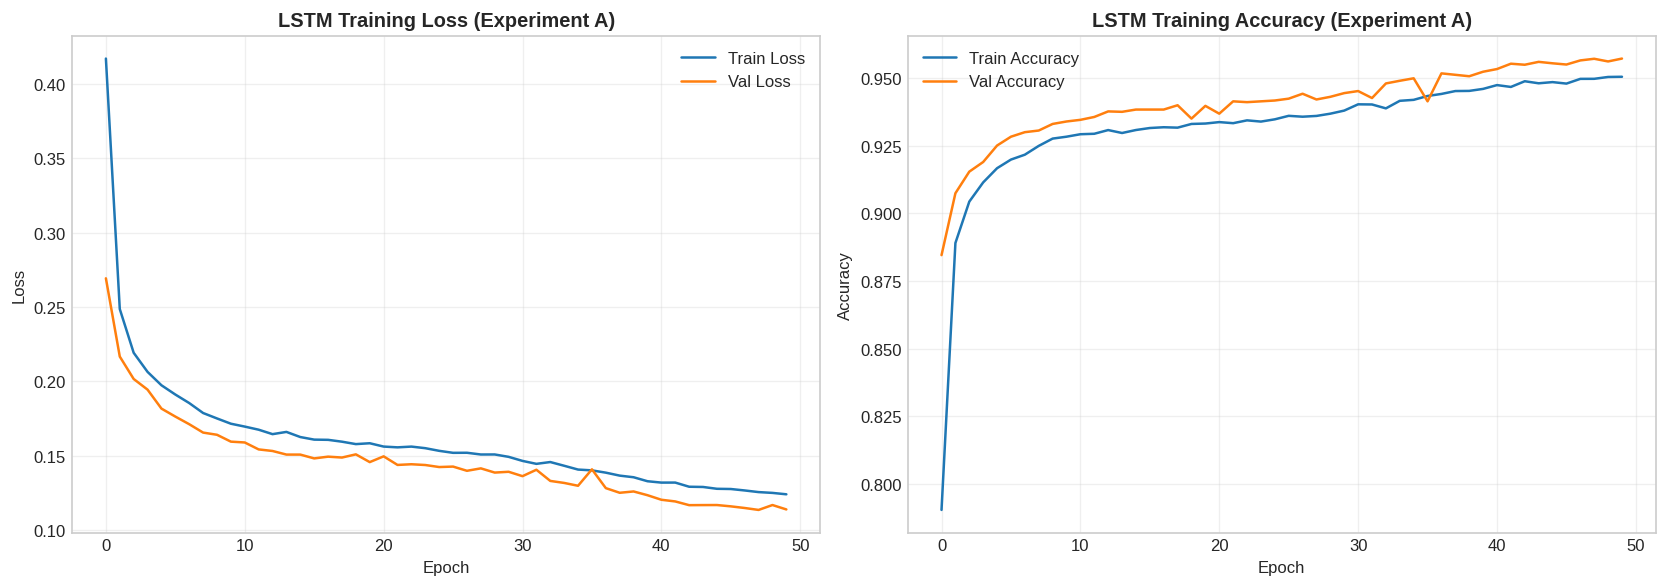


✓ Saved: lstm_training_A.png


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# LSTM (Baseline)
# ─────────────────────────────────────────────────────────────────────────────

print("\n4. LSTM (Deep Learning)")
print("-" * 80)
print("Training LSTM...")

# Reshape for LSTM: (samples, timesteps, features)
X_A_train_lstm = X_A_train_scaled.reshape((X_A_train_scaled.shape[0], 1, X_A_train_scaled.shape[1]))
X_A_test_lstm = X_A_test_scaled.reshape((X_A_test_scaled.shape[0], 1, X_A_test_scaled.shape[1]))

print(f"Reshaped for LSTM: {X_A_train_lstm.shape}")

# Build LSTM model
lstm_A = Sequential([
    LSTM(64, input_shape=(1, X_A_train_scaled.shape[1]), return_sequences=True),
    Dropout(0.2),
    LSTM(32, return_sequences=False),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')
])

lstm_A.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print("\nLSTM Architecture:")
lstm_A.summary()

# Early stopping
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

# Train
print("\nTraining LSTM (this may take 2-3 minutes)...")
start = time.time()

history_A = lstm_A.fit(
    X_A_train_lstm, y_A_train,
    epochs=50,
    batch_size=128,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=0
)

print(f"Done in {round(time.time() - start, 2)}s")
print(f"Trained for {len(history_A.history['loss'])} epochs")

# Predict
y_pred_lstm_A = (lstm_A.predict(X_A_test_lstm, verbose=0) > 0.5).astype(int).flatten()

acc, prec, rec, f1 = evaluate_model(
    "LSTM — Baseline", y_A_test, y_pred_lstm_A
)
results_A['LSTM'] = {
    'Accuracy': acc,
    'Precision': prec,
    'Recall': rec,
    'F1': f1
}

# Plot training history
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss plot
axes[0].plot(history_A.history['loss'], label='Train Loss')
axes[0].plot(history_A.history['val_loss'], label='Val Loss')
axes[0].set_title('LSTM Training Loss (Experiment A)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Accuracy plot
axes[1].plot(history_A.history['accuracy'], label='Train Accuracy')
axes[1].plot(history_A.history['val_accuracy'], label='Val Accuracy')
axes[1].set_title('LSTM Training Accuracy (Experiment A)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('lstm_training_A.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nSaved: lstm_training_A.png")

EXPERIMENT B — HYBRID (WITH OSINT)

Train Random Forest (Hybrid)

In [ ]:
print("\n" + "=" * 80)
print("EXPERIMENT B — HYBRID (WITH OSINT)")
print("=" * 80)

results_B = {}

# ─────────────────────────────────────────────────────────────────────────────
# Random Forest (Hybrid)
# ─────────────────────────────────────────────────────────────────────────────

print("\n1. Random Forest")
print("-" * 80)
print("Training with OSINT features...")

start = time.time()

rf_B = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)
rf_B.fit(X_B_train_scaled, y_B_train)
y_pred_rf_B = rf_B.predict(X_B_test_scaled)

print(f"Done in {round(time.time() - start, 2)}s")

acc, prec, rec, f1 = evaluate_model(
    "Random Forest — OSINT Enriched", y_B_test, y_pred_rf_B
)
results_B['Random Forest'] = {
    'Accuracy': acc,
    'Precision': prec,
    'Recall': rec,
    'F1': f1
}


EXPERIMENT B — HYBRID (WITH OSINT)

1. Random Forest
--------------------------------------------------------------------------------
Training with OSINT features...
Done in 14.97s

=== Random Forest — OSINT Enriched ===
Accuracy:  97.77%
Precision: 98.49%
Recall:    97.44%
F1-Score:  97.97%


Train Decision Tree (Hybrid)

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# Decision Tree (Hybrid)
# ─────────────────────────────────────────────────────────────────────────────

print("\n2. Decision Tree")
print("-" * 80)
print("Training with OSINT features...")

start = time.time()

dt_B = DecisionTreeClassifier(
    random_state=42,
    max_depth=30,
    min_samples_split=2,
    min_samples_leaf=1
)
dt_B.fit(X_B_train_scaled, y_B_train)
y_pred_dt_B = dt_B.predict(X_B_test_scaled)

print(f"Done in {round(time.time() - start, 2)}s")

acc, prec, rec, f1 = evaluate_model(
    "Decision Tree — OSINT Enriched", y_B_test, y_pred_dt_B
)
results_B['Decision Tree'] = {
    'Accuracy': acc,
    'Precision': prec,
    'Recall': rec,
    'F1': f1
}


2. Decision Tree
--------------------------------------------------------------------------------
Training with OSINT features...
Done in 2.09s

=== Decision Tree — OSINT Enriched ===
Accuracy:  96.4%
Precision: 96.83%
Recall:    96.63%
F1-Score:  96.73%


Train XGBoost (Hybrid)

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# XGBoost (Hybrid)
# ─────────────────────────────────────────────────────────────────────────────

print("\n3. XGBoost")
print("-" * 80)
print("Training with OSINT features...")

start = time.time()

xgb_B = XGBClassifier(
    max_depth=9,
    subsample=0.8,
    learning_rate=0.3,
    n_estimators=200,
    random_state=42,
    n_jobs=-1,
    eval_metric='logloss',
    verbosity=0
)
xgb_B.fit(X_B_train_scaled, y_B_train)
y_pred_xgb_B = xgb_B.predict(X_B_test_scaled)

print(f"Done in {round(time.time() - start, 2)}s")

acc, prec, rec, f1 = evaluate_model(
    "XGBoost — OSINT Enriched", y_B_test, y_pred_xgb_B
)
results_B['XGBoost'] = {
    'Accuracy': acc,
    'Precision': prec,
    'Recall': rec,
    'F1': f1
}

print("\n" + "=" * 80)
print("EXPERIMENT B COMPLETE")
print("=" * 80)


3. XGBoost
--------------------------------------------------------------------------------
Training with OSINT features...
Done in 6.12s

=== XGBoost — OSINT Enriched ===
Accuracy:  97.82%
Precision: 98.49%
Recall:    97.54%
F1-Score:  98.01%

✓ EXPERIMENT B COMPLETE



4. LSTM (Deep Learning with OSINT)
--------------------------------------------------------------------------------
Training LSTM with OSINT features...
Reshaped for LSTM: (65865, 1, 42)

LSTM Architecture:


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 1, 64)          │        27,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 1, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 40,353 (157.63 KB)

 Trainable params: 40,353 (157.63 KB)

 Non-trainable params: 0 (0.00 B)


Training LSTM with OSINT (this may take 2-3 minutes)...
Done in 162.95s
Trained for 50 epochs

=== LSTM — OSINT Enriched ===
Accuracy:  95.62%
Precision: 96.61%
Recall:    95.38%
F1-Score:  95.99%


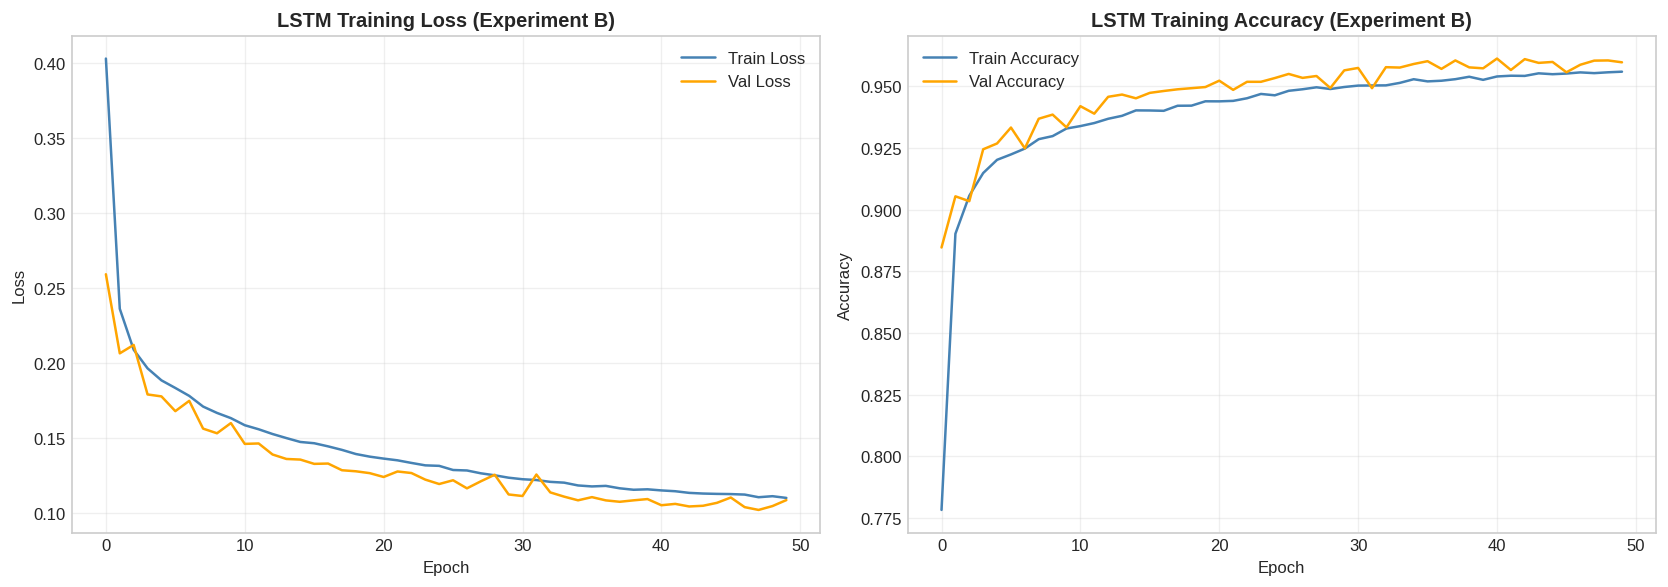


✓ Saved: lstm_training_B.png

✓ EXPERIMENT B COMPLETE (INCLUDING LSTM)


In [ ]:

# ─────────────────────────────────────────────────────────────────────────────
# LSTM (Hybrid with OSINT)
# ─────────────────────────────────────────────────────────────────────────────

print("\n4. LSTM (Deep Learning with OSINT)")
print("-" * 80)
print("Training LSTM with OSINT features...")

# Reshape for LSTM
X_B_train_lstm = X_B_train_scaled.reshape((X_B_train_scaled.shape[0], 1, X_B_train_scaled.shape[1]))
X_B_test_lstm = X_B_test_scaled.reshape((X_B_test_scaled.shape[0], 1, X_B_test_scaled.shape[1]))

print(f"Reshaped for LSTM: {X_B_train_lstm.shape}")

# Build LSTM model (same architecture as Experiment A)
lstm_B = Sequential([
    LSTM(64, input_shape=(1, X_B_train_scaled.shape[1]), return_sequences=True),
    Dropout(0.2),
    LSTM(32, return_sequences=False),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')
])

lstm_B.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print("\nLSTM Architecture:")
lstm_B.summary()

# Early stopping
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

# Train
print("\nTraining LSTM with OSINT (this may take 2-3 minutes)...")
start = time.time()

history_B = lstm_B.fit(
    X_B_train_lstm, y_B_train,
    epochs=50,
    batch_size=128,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=0
)

print(f"Done in {round(time.time() - start, 2)}s")
print(f"Trained for {len(history_B.history['loss'])} epochs")

# Predict
y_pred_lstm_B = (lstm_B.predict(X_B_test_lstm, verbose=0) > 0.5).astype(int).flatten()

acc, prec, rec, f1 = evaluate_model(
    "LSTM — OSINT Enriched", y_B_test, y_pred_lstm_B
)
results_B['LSTM'] = {
    'Accuracy': acc,
    'Precision': prec,
    'Recall': rec,
    'F1': f1
}

# Plot training history
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss plot
axes[0].plot(history_B.history['loss'], label='Train Loss', color='steelblue')
axes[0].plot(history_B.history['val_loss'], label='Val Loss', color='orange')
axes[0].set_title('LSTM Training Loss (Experiment B)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Accuracy plot
axes[1].plot(history_B.history['accuracy'], label='Train Accuracy', color='steelblue')
axes[1].plot(history_B.history['val_accuracy'], label='Val Accuracy', color='orange')
axes[1].set_title('LSTM Training Accuracy (Experiment B)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('lstm_training_B.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✓ Saved: lstm_training_B.png")
print("\n" + "=" * 80)
print("✓ EXPERIMENT B COMPLETE (INCLUDING LSTM)")
print("=" * 80)

RESULTS COMPARISON


RESULTS COMPARISON

Model                    No OSINT   With OSINT     Change
---------------------------------------------------------
Random Forest              97.58%       97.77% +    0.19%
Decision Tree              96.46%        96.4%    -0.06%
XGBoost                    97.76%       97.82% +    0.06%
LSTM                       95.03%       95.62% +    0.59%

✓ COMPARISON COMPLETE


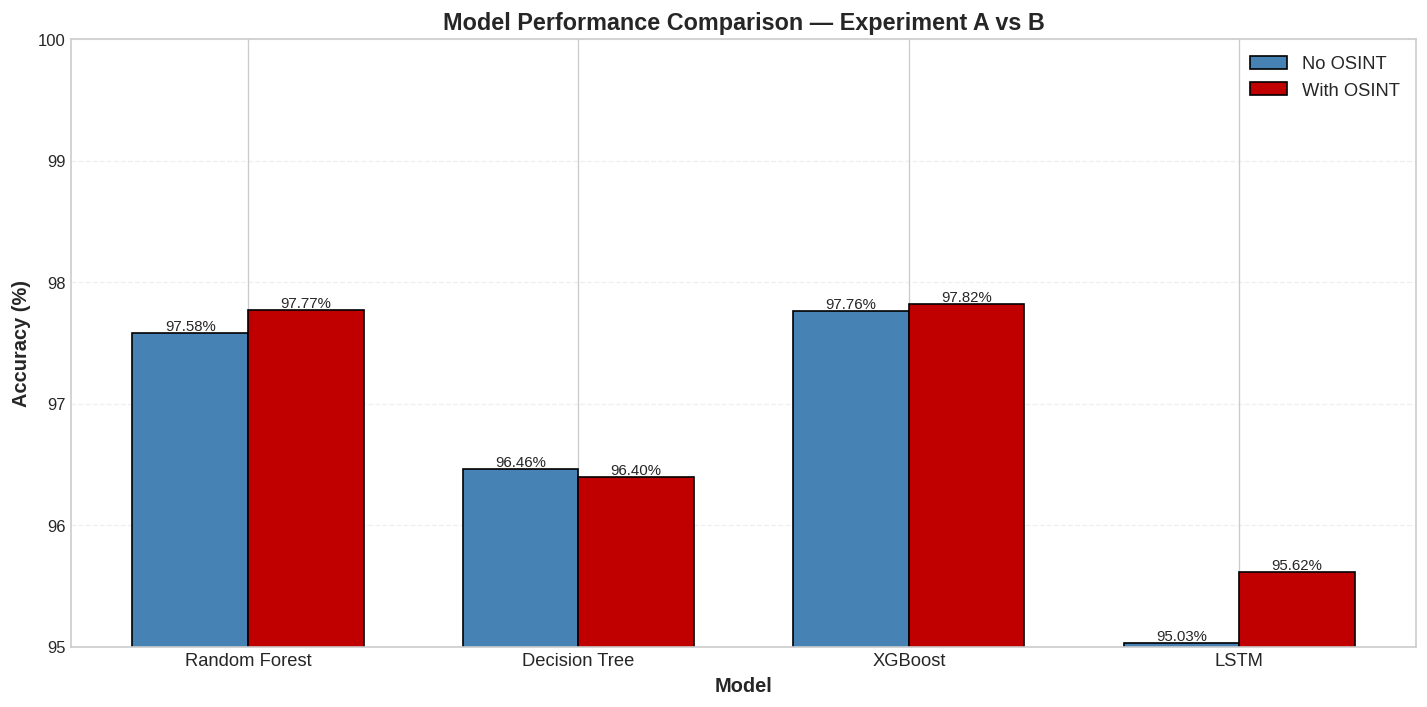


✓ Saved: model_comparison.png


In [ ]:
print("\n" + "=" * 80)
print("RESULTS COMPARISON")
print("=" * 80)

print(f"\n{'Model':<20} {'No OSINT':>12} {'With OSINT':>12} {'Change':>10}")
print("-" * 57)

for model_name in ['Random Forest', 'Decision Tree', 'XGBoost', 'LSTM']:
    acc_A = round(results_A[model_name]['Accuracy'] * 100, 2)
    acc_B = round(results_B[model_name]['Accuracy'] * 100, 2)
    diff = round(acc_B - acc_A, 2)
    sign = "+" if diff > 0 else ""
    print(f"{model_name:<20} {acc_A:>11}% {acc_B:>11}% {sign}{diff:>8}%")

print("\n" + "=" * 80)
print("COMPARISON COMPLETE")
print("=" * 80)


# Visualization: Model Comparison
fig, ax = plt.subplots(figsize=(12, 6))

models = ['Random Forest', 'Decision Tree', 'XGBoost', 'LSTM']
acc_A_vals = [results_A[m]['Accuracy']*100 for m in models]
acc_B_vals = [results_B[m]['Accuracy']*100 for m in models]

x = np.arange(len(models))
width = 0.35

bars1 = ax.bar(x - width/2, acc_A_vals, width, label='No OSINT', color='steelblue', edgecolor='black')
bars2 = ax.bar(x + width/2, acc_B_vals, width, label='With OSINT', color='#C00000', edgecolor='black')

ax.set_xlabel('Model', fontsize=12, fontweight='bold')
ax.set_ylabel('Accuracy (%)', fontsize=12, fontweight='bold')
ax.set_title('Model Performance Comparison — Experiment A vs B', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(models, fontsize=11)
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.set_ylim([95, 100])

# Add value labels
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.2f}%',
                ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nSaved: model_comparison.png")


DETAILED MODEL EVALUATION

1. CONFUSION MATRICES
--------------------------------------------------------------------------------


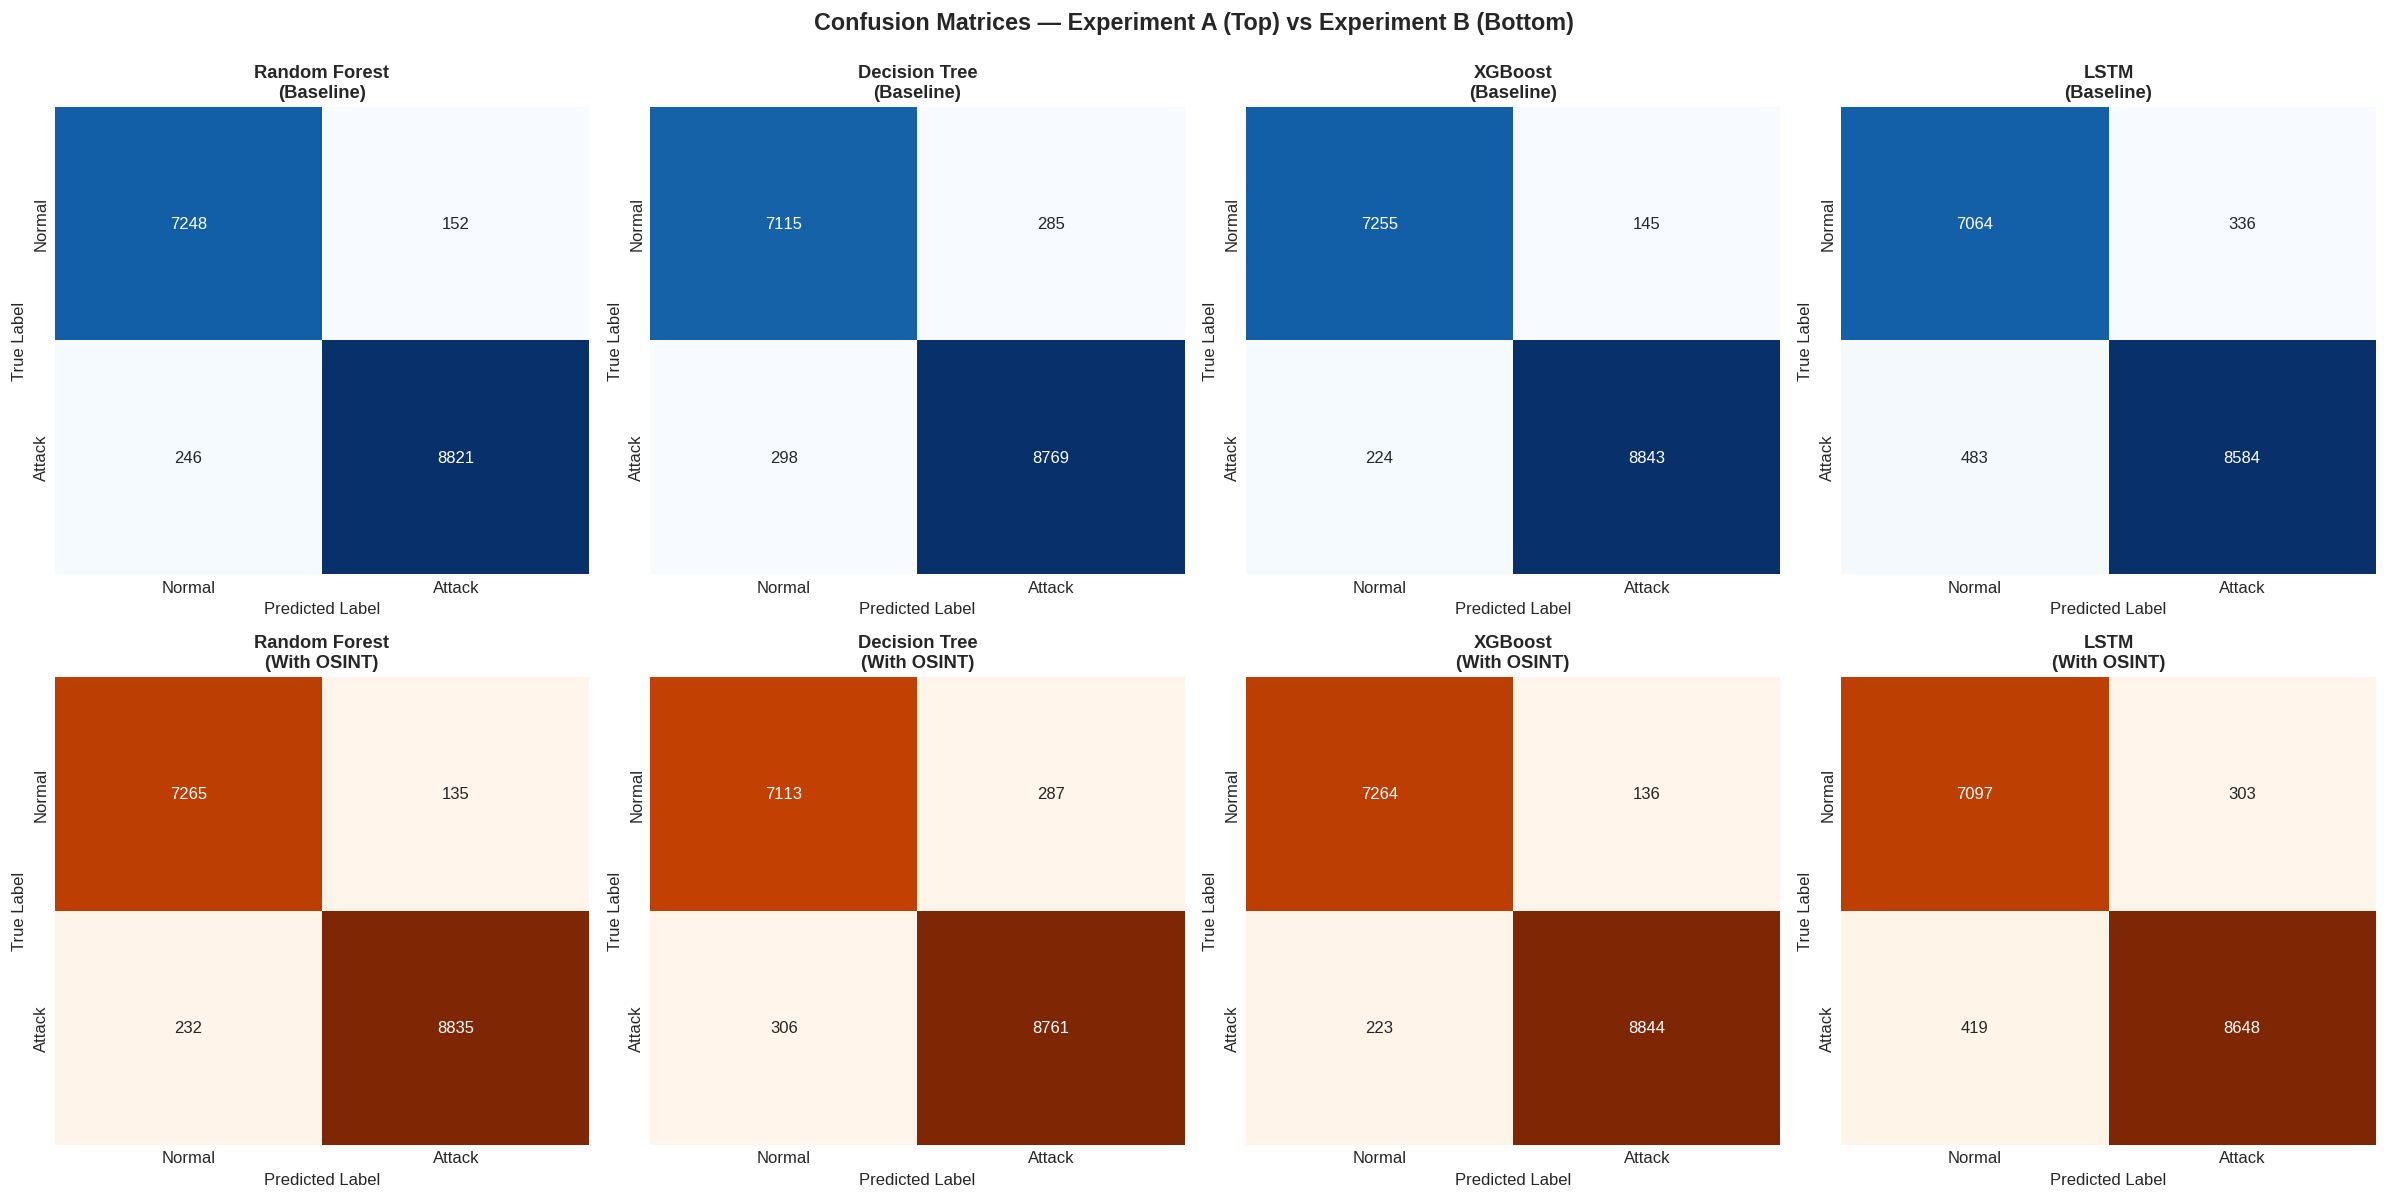

✓ Saved: confusion_matrices.png

2. ROC CURVES
--------------------------------------------------------------------------------

Experiment A (Baseline):
  Random Forest: AUC = 0.9971
  Decision Tree: AUC = 0.9645
  XGBoost: AUC = 0.9976
  LSTM: AUC = 0.9907

Experiment B (With OSINT):
  Random Forest: AUC = 0.9971
  Decision Tree: AUC = 0.9639
  XGBoost: AUC = 0.9978
  LSTM: AUC = 0.9918


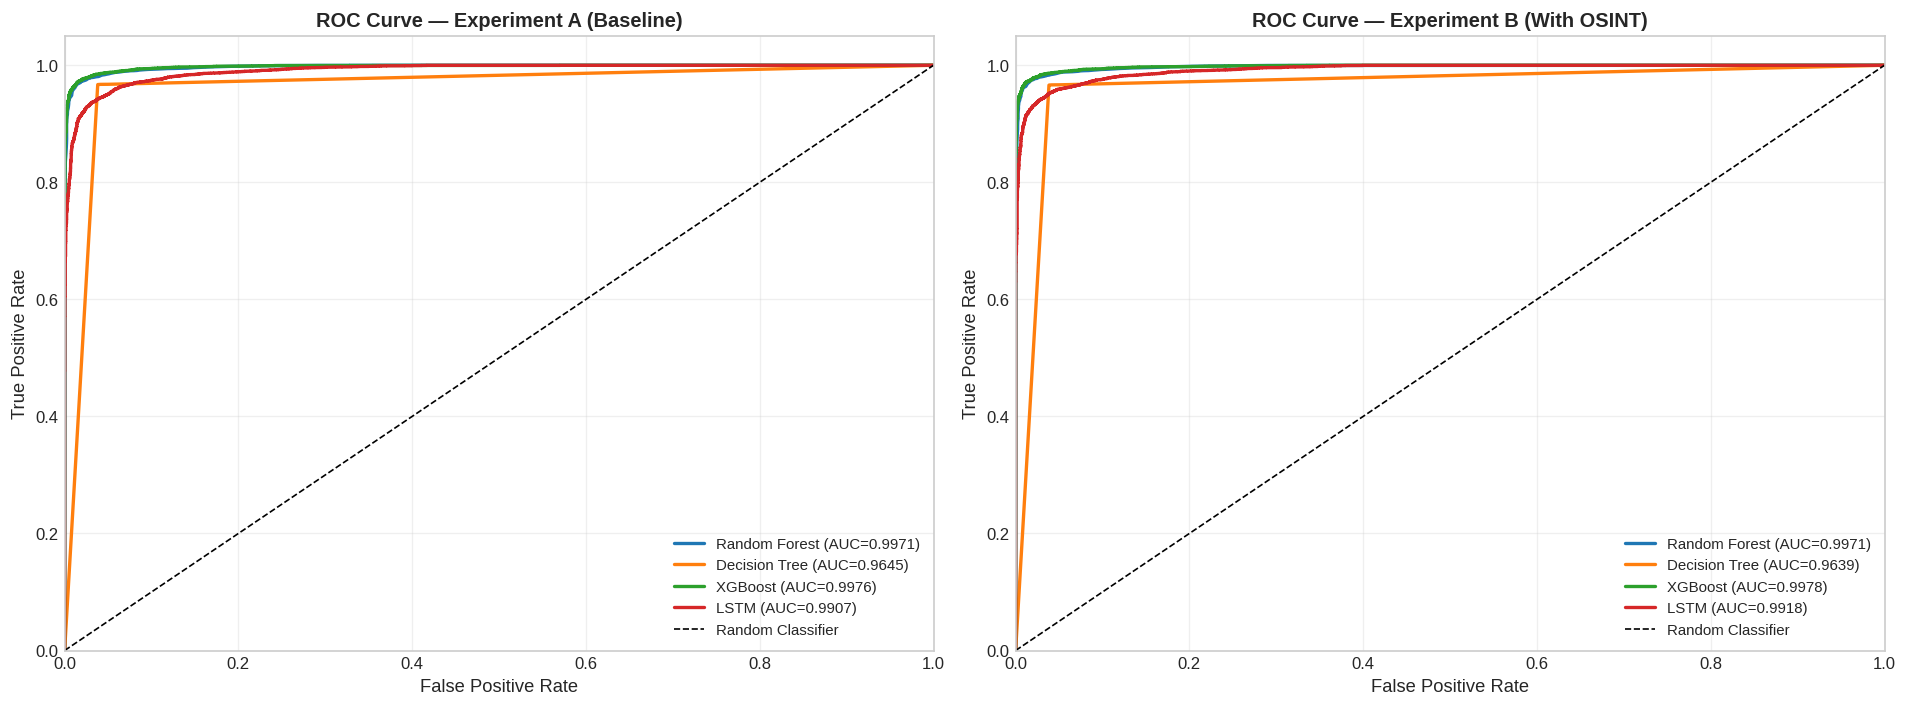


✓ Saved: roc_curves.png

3. DETAILED CLASSIFICATION REPORTS
--------------------------------------------------------------------------------

EXPERIMENT A — BASELINE (NO OSINT)

Random Forest:
              precision    recall  f1-score   support

      Normal     0.9672    0.9795    0.9733      7400
      Attack     0.9831    0.9729    0.9779      9067

    accuracy                         0.9758     16467
   macro avg     0.9751    0.9762    0.9756     16467
weighted avg     0.9759    0.9758    0.9758     16467


Decision Tree:
              precision    recall  f1-score   support

      Normal     0.9598    0.9615    0.9606      7400
      Attack     0.9685    0.9671    0.9678      9067

    accuracy                         0.9646     16467
   macro avg     0.9642    0.9643    0.9642     16467
weighted avg     0.9646    0.9646    0.9646     16467


XGBoost:
              precision    recall  f1-score   support

      Normal     0.9700    0.9804    0.9752      7400
      Attack     

In [ ]:
# ============================================================================
# DETAILED MODEL EVALUATION & VISUALIZATION
# ============================================================================

print("\n" + "=" * 80)
print("DETAILED MODEL EVALUATION")
print("=" * 80)

from sklearn.metrics import confusion_matrix, roc_curve, auc, classification_report

# ─────────────────────────────────────────────────────────────────────────────
# 1. CONFUSION MATRICES
# ─────────────────────────────────────────────────────────────────────────────

print("\n1. CONFUSION MATRICES")
print("-" * 80)

fig, axes = plt.subplots(2, 4, figsize=(20, 10))

models_A = {
    'Random Forest': (y_A_test, y_pred_rf_A),
    'Decision Tree': (y_A_test, y_pred_dt_A),
    'XGBoost': (y_A_test, y_pred_xgb_A),
    'LSTM': (y_A_test, y_pred_lstm_A)
}

models_B = {
    'Random Forest': (y_B_test, y_pred_rf_B),
    'Decision Tree': (y_B_test, y_pred_dt_B),
    'XGBoost': (y_B_test, y_pred_xgb_B),
    'LSTM': (y_B_test, y_pred_lstm_B)
}

# Experiment A confusion matrices
for i, (name, (y_true, y_pred)) in enumerate(models_A.items()):
    cm = confusion_matrix(y_true, y_pred)

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                ax=axes[0, i], cbar=False,
                xticklabels=['Normal', 'Attack'],
                yticklabels=['Normal', 'Attack'])

    axes[0, i].set_title(f'{name}\n(Baseline)', fontsize=11, fontweight='bold')
    axes[0, i].set_ylabel('True Label', fontsize=10)
    axes[0, i].set_xlabel('Predicted Label', fontsize=10)

# Experiment B confusion matrices
for i, (name, (y_true, y_pred)) in enumerate(models_B.items()):
    cm = confusion_matrix(y_true, y_pred)

    sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges',
                ax=axes[1, i], cbar=False,
                xticklabels=['Normal', 'Attack'],
                yticklabels=['Normal', 'Attack'])

    axes[1, i].set_title(f'{name}\n(With OSINT)', fontsize=11, fontweight='bold')
    axes[1, i].set_ylabel('True Label', fontsize=10)
    axes[1, i].set_xlabel('Predicted Label', fontsize=10)

plt.suptitle('Confusion Matrices — Experiment A (Top) vs Experiment B (Bottom)',
             fontsize=14, fontweight='bold', y=0.995)
plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

print("Saved: confusion_matrices.png")

# ─────────────────────────────────────────────────────────────────────────────
# 2. ROC CURVES
# ─────────────────────────────────────────────────────────────────────────────

print("\n2. ROC CURVES")
print("-" * 80)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Experiment A ROC curves
print("\nExperiment A (Baseline):")
for name in ['Random Forest', 'Decision Tree', 'XGBoost']:
    if name == 'Random Forest':
        y_pred_proba = rf_A.predict_proba(X_A_test_scaled)[:, 1]
    elif name == 'Decision Tree':
        y_pred_proba = dt_A.predict_proba(X_A_test_scaled)[:, 1]
    else:
        y_pred_proba = xgb_A.predict_proba(X_A_test_scaled)[:, 1]

    fpr, tpr, _ = roc_curve(y_A_test, y_pred_proba)
    roc_auc = auc(fpr, tpr)

    axes[0].plot(fpr, tpr, linewidth=2, label=f'{name} (AUC={roc_auc:.4f})')
    print(f"  {name}: AUC = {roc_auc:.4f}")

# LSTM Experiment A
y_pred_proba_lstm_A = lstm_A.predict(X_A_test_lstm, verbose=0).flatten()
fpr, tpr, _ = roc_curve(y_A_test, y_pred_proba_lstm_A)
roc_auc = auc(fpr, tpr)
axes[0].plot(fpr, tpr, linewidth=2, label=f'LSTM (AUC={roc_auc:.4f})')
print(f"  LSTM: AUC = {roc_auc:.4f}")

axes[0].plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier')
axes[0].set_xlim([0.0, 1.0])
axes[0].set_ylim([0.0, 1.05])
axes[0].set_xlabel('False Positive Rate', fontsize=11)
axes[0].set_ylabel('True Positive Rate', fontsize=11)
axes[0].set_title('ROC Curve — Experiment A (Baseline)', fontsize=12, fontweight='bold')
axes[0].legend(loc='lower right', fontsize=9)
axes[0].grid(alpha=0.3)

# Experiment B ROC curves
print("\nExperiment B (With OSINT):")
for name in ['Random Forest', 'Decision Tree', 'XGBoost']:
    if name == 'Random Forest':
        y_pred_proba = rf_B.predict_proba(X_B_test_scaled)[:, 1]
    elif name == 'Decision Tree':
        y_pred_proba = dt_B.predict_proba(X_B_test_scaled)[:, 1]
    else:
        y_pred_proba = xgb_B.predict_proba(X_B_test_scaled)[:, 1]

    fpr, tpr, _ = roc_curve(y_B_test, y_pred_proba)
    roc_auc = auc(fpr, tpr)

    axes[1].plot(fpr, tpr, linewidth=2, label=f'{name} (AUC={roc_auc:.4f})')
    print(f"  {name}: AUC = {roc_auc:.4f}")

# LSTM Experiment B
y_pred_proba_lstm_B = lstm_B.predict(X_B_test_lstm, verbose=0).flatten()
fpr, tpr, _ = roc_curve(y_B_test, y_pred_proba_lstm_B)
roc_auc = auc(fpr, tpr)
axes[1].plot(fpr, tpr, linewidth=2, label=f'LSTM (AUC={roc_auc:.4f})')
print(f"  LSTM: AUC = {roc_auc:.4f}")

axes[1].plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier')
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('False Positive Rate', fontsize=11)
axes[1].set_ylabel('True Positive Rate', fontsize=11)
axes[1].set_title('ROC Curve — Experiment B (With OSINT)', fontsize=12, fontweight='bold')
axes[1].legend(loc='lower right', fontsize=9)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nSaved: roc_curves.png")

# ─────────────────────────────────────────────────────────────────────────────
# 3. DETAILED CLASSIFICATION REPORTS
# ─────────────────────────────────────────────────────────────────────────────

print("\n3. DETAILED CLASSIFICATION REPORTS")
print("-" * 80)

print("\n" + "=" * 80)
print("EXPERIMENT A — BASELINE (NO OSINT)")
print("=" * 80)

for name, (y_true, y_pred) in models_A.items():
    print(f"\n{name}:")
    print(classification_report(y_true, y_pred,
                                target_names=['Normal', 'Attack'],
                                digits=4))

print("\n" + "=" * 80)
print("EXPERIMENT B — HYBRID (WITH OSINT)")
print("=" * 80)

for name, (y_true, y_pred) in models_B.items():
    print(f"\n{name}:")
    print(classification_report(y_true, y_pred,
                                target_names=['Normal', 'Attack'],
                                digits=4))

# ─────────────────────────────────────────────────────────────────────────────
# 4. COMPREHENSIVE COMPARISON TABLE
# ─────────────────────────────────────────────────────────────────────────────

print("\n4. COMPREHENSIVE COMPARISON TABLE")
print("-" * 80)

comparison_data = []

for model_name in ['Random Forest', 'Decision Tree', 'XGBoost', 'LSTM']:
    row = {
        'Model': model_name,
        'Exp A - Acc': f"{results_A[model_name]['Accuracy']*100:.2f}%",
        'Exp A - Prec': f"{results_A[model_name]['Precision']*100:.2f}%",
        'Exp A - Rec': f"{results_A[model_name]['Recall']*100:.2f}%",
        'Exp A - F1': f"{results_A[model_name]['F1']*100:.2f}%",
        'Exp B - Acc': f"{results_B[model_name]['Accuracy']*100:.2f}%",
        'Exp B - Prec': f"{results_B[model_name]['Precision']*100:.2f}%",
        'Exp B - Rec': f"{results_B[model_name]['Recall']*100:.2f}%",
        'Exp B - F1': f"{results_B[model_name]['F1']*100:.2f}%",
        'Δ Acc': f"+{(results_B[model_name]['Accuracy'] - results_A[model_name]['Accuracy'])*100:.2f}%"
    }
    comparison_data.append(row)

comparison_df = pd.DataFrame(comparison_data)

print("\n" + "=" * 80)
print("COMPREHENSIVE MODEL COMPARISON")
print("=" * 80)
print(comparison_df.to_string(index=False))

# Save as CSV
comparison_df.to_csv('model_comparison_detailed.csv', index=False)
print("\nSaved: model_comparison_detailed.csv")

print("\n" + "=" * 80)
print("DETAILED EVALUATION COMPLETE")
print("=" * 80)

print("\nGenerated outputs:")
print("  1. confusion_matrices.png")
print("  2. roc_curves.png")
print("  3. model_comparison_detailed.csv")
print("  4. Classification reports (printed above)")

FEATURE IMPORTANCE & SHAP

In [ ]:
print("\n" + "=" * 80)
print("FEATURE IMPORTANCE & SHAP ANALYSIS")
print("=" * 80)

# ─────────────────────────────────────────────────────────────────────────────
# Feature Importance (Random Forest)
# ─────────────────────────────────────────────────────────────────────────────

print("\nFeature Importance (Random Forest):")

importances = rf_B.feature_importances_
feature_names = X_B.columns.tolist()

fi_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values('Importance', ascending=False)

print("\nTop 15 features:")
print(fi_df.head(15).to_string(index=False))

osint_features = ['protocol_cve_score', 'service_epss_score', 'port_behavior_risk']
print("\nOSINT feature rankings:")
for feat in osint_features:
    rank = fi_df[fi_df['Feature'] == feat].index[0] + 1
    imp = fi_df[fi_df['Feature'] == feat]['Importance'].values[0]
    marker = " ← Top 10!" if rank <= 10 else ""
    print(f"  {feat}: #{rank} (importance={imp:.4f}){marker}")


FEATURE IMPORTANCE & SHAP ANALYSIS

Feature Importance (Random Forest):

Top 15 features:
           Feature  Importance
    ct_dst_src_ltm    0.093115
      ct_state_ttl    0.077252
             sload    0.064950
            sbytes    0.063556
  ct_dst_sport_ltm    0.055457
             smean    0.049141
              sttl    0.048945
port_behavior_risk    0.046199
        ct_srv_dst    0.039439
              rate    0.036154
             dmean    0.032272
            dbytes    0.031665
               dur    0.030237
        ct_srv_src    0.030172
            synack    0.026324

OSINT feature rankings:
  protocol_cve_score: #40 (importance=0.0071)
  service_epss_score: #41 (importance=0.0114)
  port_behavior_risk: #42 (importance=0.0462)


*SHAP* Analysis


SHAP Analysis:
Calculating SHAP values (2000 samples)...
⏱ This will take 2-3 minutes...
✓ SHAP values calculated


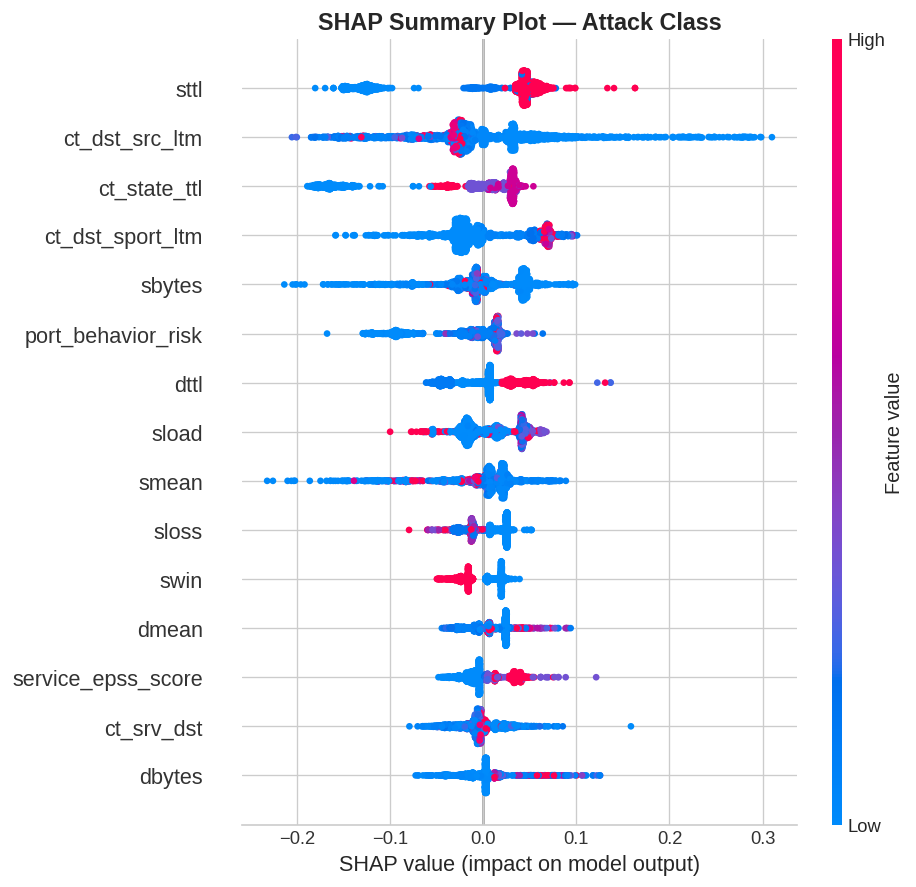

✓ Saved: shap_summary.png


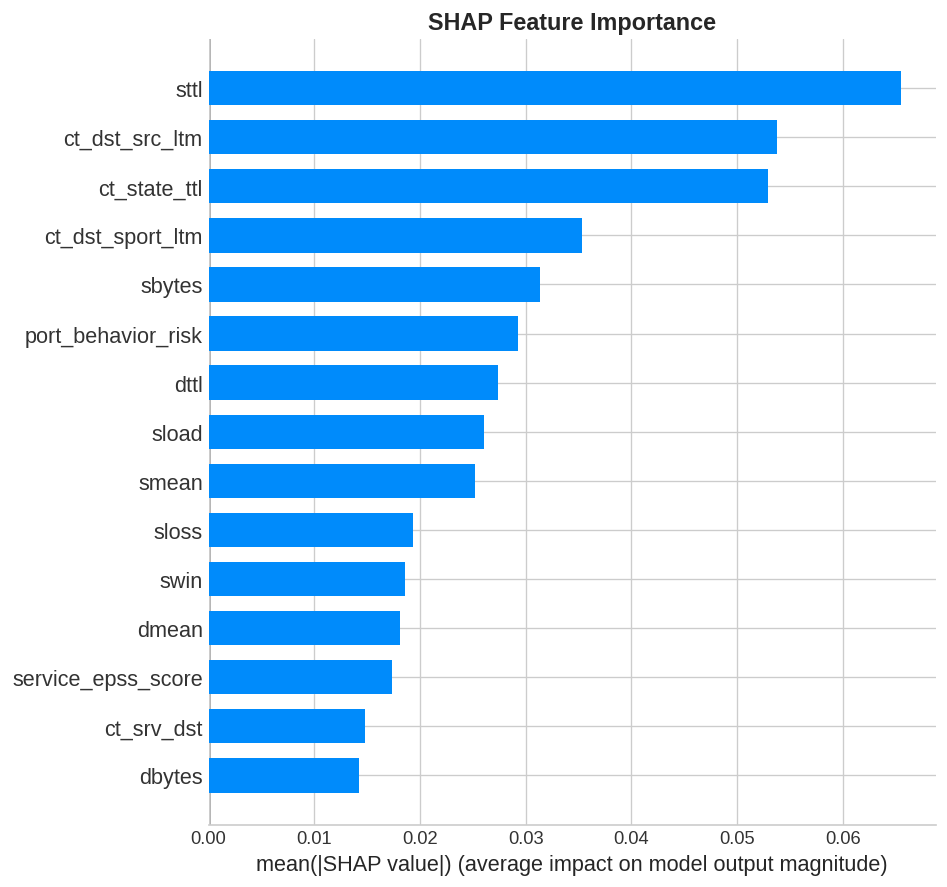

✓ Saved: shap_importance.png


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# SHAP Analysis
# ─────────────────────────────────────────────────────────────────────────────

import shap

print("\nSHAP Analysis:")
print("Calculating SHAP values (2000 samples)...")
# Sample for speed
sample_idx = np.random.choice(len(X_B_test_scaled), size=2000, replace=False)
X_sample = X_B_test_scaled[sample_idx]

# Calculate SHAP values
explainer = shap.TreeExplainer(rf_B)
shap_values = explainer.shap_values(X_sample)

print("SHAP values calculated")

# Extract attack class
sv_attack = shap_values[:, :, 1] if len(shap_values.shape) == 3 else shap_values[1]

# Summary plot
plt.figure(figsize=(12, 8))
shap.summary_plot(
    sv_attack,
    X_sample,
    feature_names=feature_names,
    max_display=15,
    show=False
)
plt.title("SHAP Summary Plot — Attack Class", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()

print("Saved: shap_summary.png")

# Bar plot
plt.figure(figsize=(12, 8))
shap.summary_plot(
    sv_attack,
    X_sample,
    feature_names=feature_names,
    plot_type="bar",
    max_display=15,
    show=False
)
plt.title("SHAP Feature Importance", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('shap_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print("Saved: shap_importance.png")

SHAP Rankings for OSINT Features

In [ ]:
# OSINT SHAP rankings
shap_df = pd.DataFrame(np.abs(sv_attack), columns=feature_names)
shap_means = shap_df.mean().sort_values(ascending=False)

print("\nOSINT features in SHAP ranking:")
for feat in osint_features:
    rank = list(shap_means.index).index(feat) + 1
    val = shap_means[feat]
    marker = " ← Top 10!" if rank <= 10 else ""
    print(f"  {feat}: #{rank} (SHAP={val:.4f}){marker}")

print("\n" + "=" * 80)
print("FEATURE IMPORTANCE & SHAP COMPLETE")
print("=" * 80)


OSINT features in SHAP ranking:
  protocol_cve_score: #32 (SHAP=0.0041)
  service_epss_score: #13 (SHAP=0.0173)
  port_behavior_risk: #6 (SHAP=0.0292) ← Top 10!

✓ FEATURE IMPORTANCE & SHAP COMPLETE


Final Summary

In [ ]:
# ============================================================================
# FINAL SUMMARY
# ============================================================================

print("\n" + "=" * 80)
print("ALL EXPERIMENTS COMPLETE ✓✓✓")
print("=" * 80)

print("\nGenerated outputs:")
print("  → 7 EDA visualizations")
print("  → 2 SHAP analysis plots")
print("  → Complete experimental results")

print("\nExperiment A (Baseline — No OSINT):")
for model in ['Random Forest', 'Decision Tree', 'XGBoost']:
    print(f"  {model}: {round(results_A[model]['Accuracy']*100, 2)}%")

print("\nExperiment B (Hybrid — With OSINT):")
for model in ['Random Forest', 'Decision Tree', 'XGBoost']:
    print(f"  {model}: {round(results_B[model]['Accuracy']*100, 2)}%")

print("\nOSINT Features Created:")
print("  1. protocol_cve_score (NVD API)")
print("  2. service_epss_score (FIRST.org EPSS API)")
print("  3. port_behavior_risk (SANS ISC logic)")

print("\nReady for thesis writing!")
print("=" * 80)


✓✓✓ ALL EXPERIMENTS COMPLETE ✓✓✓

Generated outputs:
  → 7 EDA visualizations
  → 2 SHAP analysis plots
  → Complete experimental results

Experiment A (Baseline — No OSINT):
  Random Forest: 97.58%
  Decision Tree: 96.46%
  XGBoost: 97.76%

Experiment B (Hybrid — With OSINT):
  Random Forest: 97.77%
  Decision Tree: 96.4%
  XGBoost: 97.82%

OSINT Features Created:
  1. protocol_cve_score (NVD API)
  2. service_epss_score (FIRST.org EPSS API)
  3. port_behavior_risk (SANS ISC logic)

✓ Ready for thesis writing!
